In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pickle

from neurolib.models.wc import WCModel
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics
import pandas as pd
import seaborn as sns

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
label_size= 30
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1
plt.rcParams['text.usetex'] = True

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Modern"
})

def ploterrorrange(a, x_axis, linfit, linfitstd):
    xpos = np.linspace(0., x_axis[-1], 100)
    a.fill_between(xpos, linfit[1]-linfitstd[1] + xpos*(linfit[0]-linfitstd[0]), linfit[1] + xpos*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xpos, linfit[1] + xpos*linfit[0], linfit[1]+linfitstd[1] + xpos*(linfit[0]+linfitstd[0]), color="red", alpha=0.3 )
    xneg = np.linspace(x_axis[0], -1e-3, 100, )
    a.fill_between(xneg, linfit[1]-linfitstd[1] + xneg*(linfit[0]+linfitstd[0]), linfit[1] + xneg*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xneg, linfit[1] + xneg*linfit[0], linfit[1]+linfitstd[1] + xneg*(linfit[0]-linfitstd[0]), color="red", alpha=0.3 )

def get_sphere_coords(x,y,z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z/r)
    phi = np.sign(y)*np.arccos(x/np.sqrt(x**2 + y**2))
    return r, theta, phi

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()

/tmp/ipykernel_475329/854259224.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()


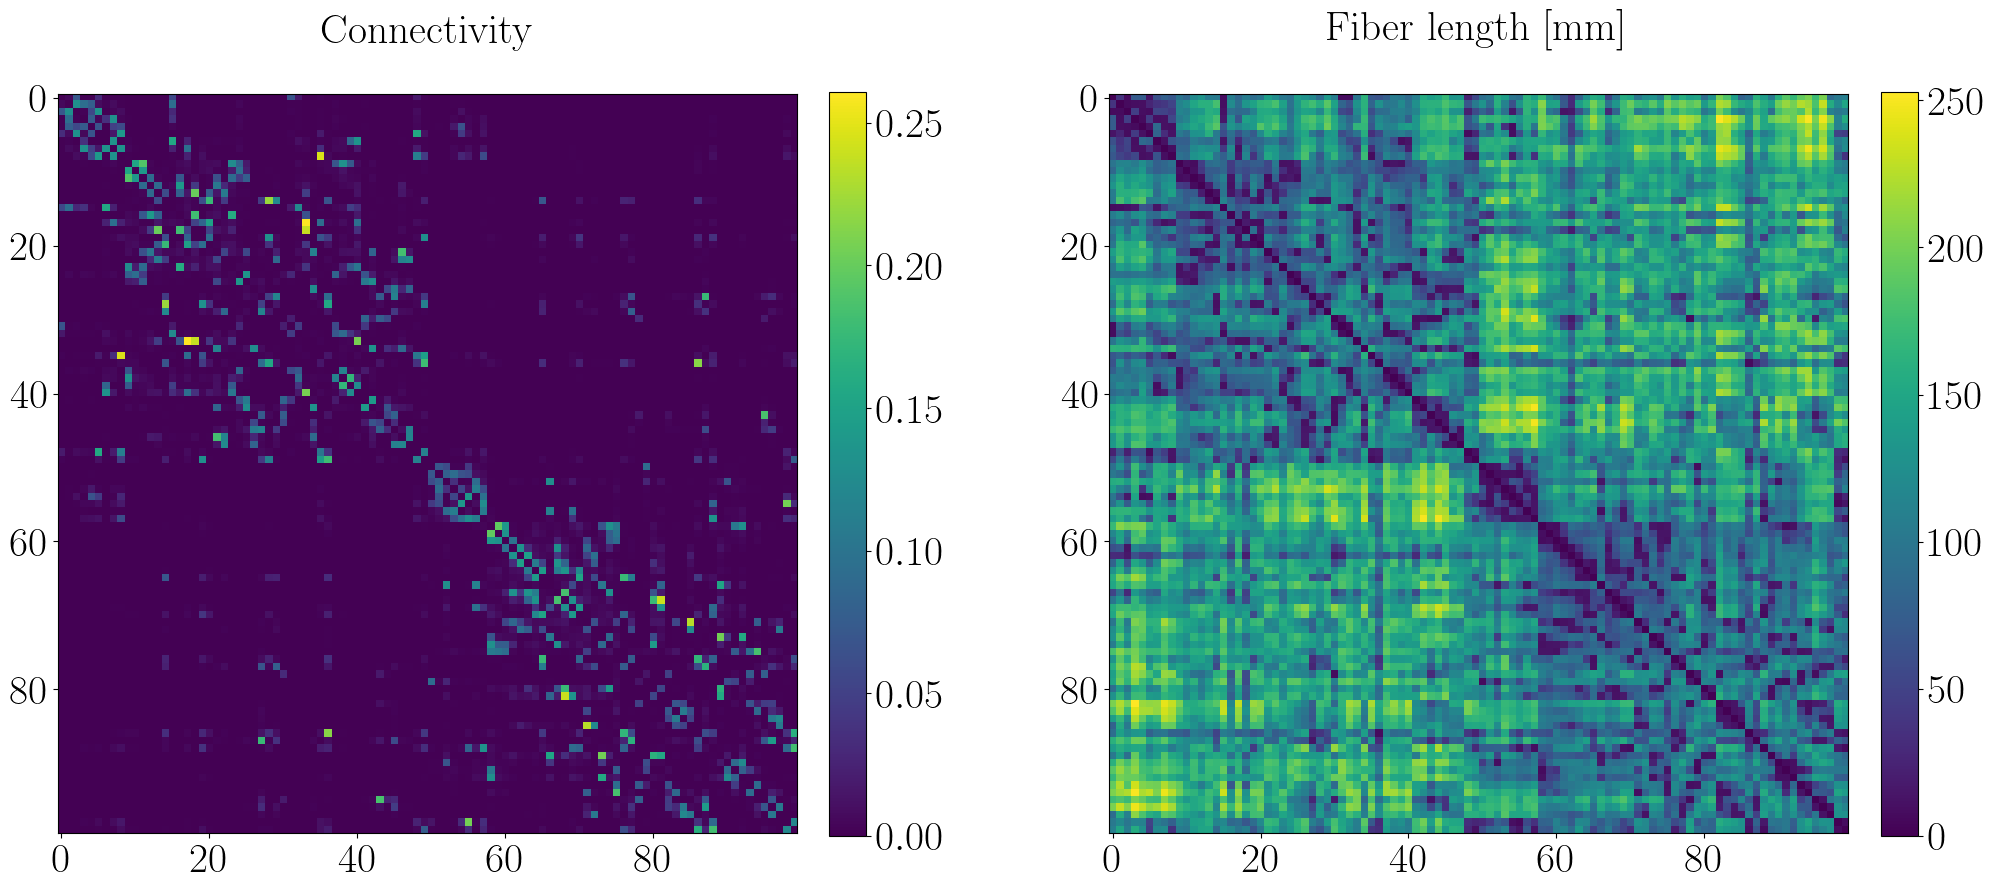

In [422]:
fig, ax = plt.subplots(1,2, figsize=(24,12))

ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')

heatmap = ax[0].imshow(cmat_av)
ax[0].set_title("Connectivity\n")
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)

heatmap = ax[1].imshow(dmat_av)
ax[1].set_title("Fiber length [mm]\n")
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)

plt.savefig(os.path.join(datadir, "cd_mat.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [234]:
sys = "discrete"

c_norm = nctpy.utils.matrix_normalization((cmat_av), system=sys)
av_c = nctpy.metrics.ave_control(c_norm, sys)
mod_c = nctpy.metrics.modal_control(c_norm)
wnd = np.sum(cmat_av, axis=0)
nfl = np.sum(dmat_av, axis=0)

nfl /= 1e3

wnfl = np.zeros((N))
for n in range(N):
    wnfl[n] = sum(cmat_av[n,:]*dmat_av[n,:])

r_coord, theta, phi = get_sphere_coords(coord_data[:,0], coord_data[:,1], coord_data[:,2])

rng = np.random.default_rng()
method = scipy.stats.PermutationMethod(n_resamples=1. * 1e3, random_state=rng)
cmap = "cividis"

In [40]:
x_array = [av_c, mod_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r_coord]
xlabel = ["Average controllability", "Modal controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]

r_mat_cd_cd = np.zeros((len(x_array), len(x_array)))
p_mat_cd_cd = np.zeros((len(x_array), len(x_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(x_array):

        if iy == ix: 
            r_mat_cd_cd[ix, iy] = 1.
            p_mat_cd_cd[ix, iy] = 0.

        if iy >= ix: continue

        result = scipy.stats.pearsonr(x, y, method=method)
        r_val = result.statistic
        p_val = result.pvalue
        r_mat_cd_cd[ix, iy] = r_val
        r_mat_cd_cd[iy, ix] = r_val
        p_mat_cd_cd[ix, iy] = p_val
        p_mat_cd_cd[iy, ix] = p_val

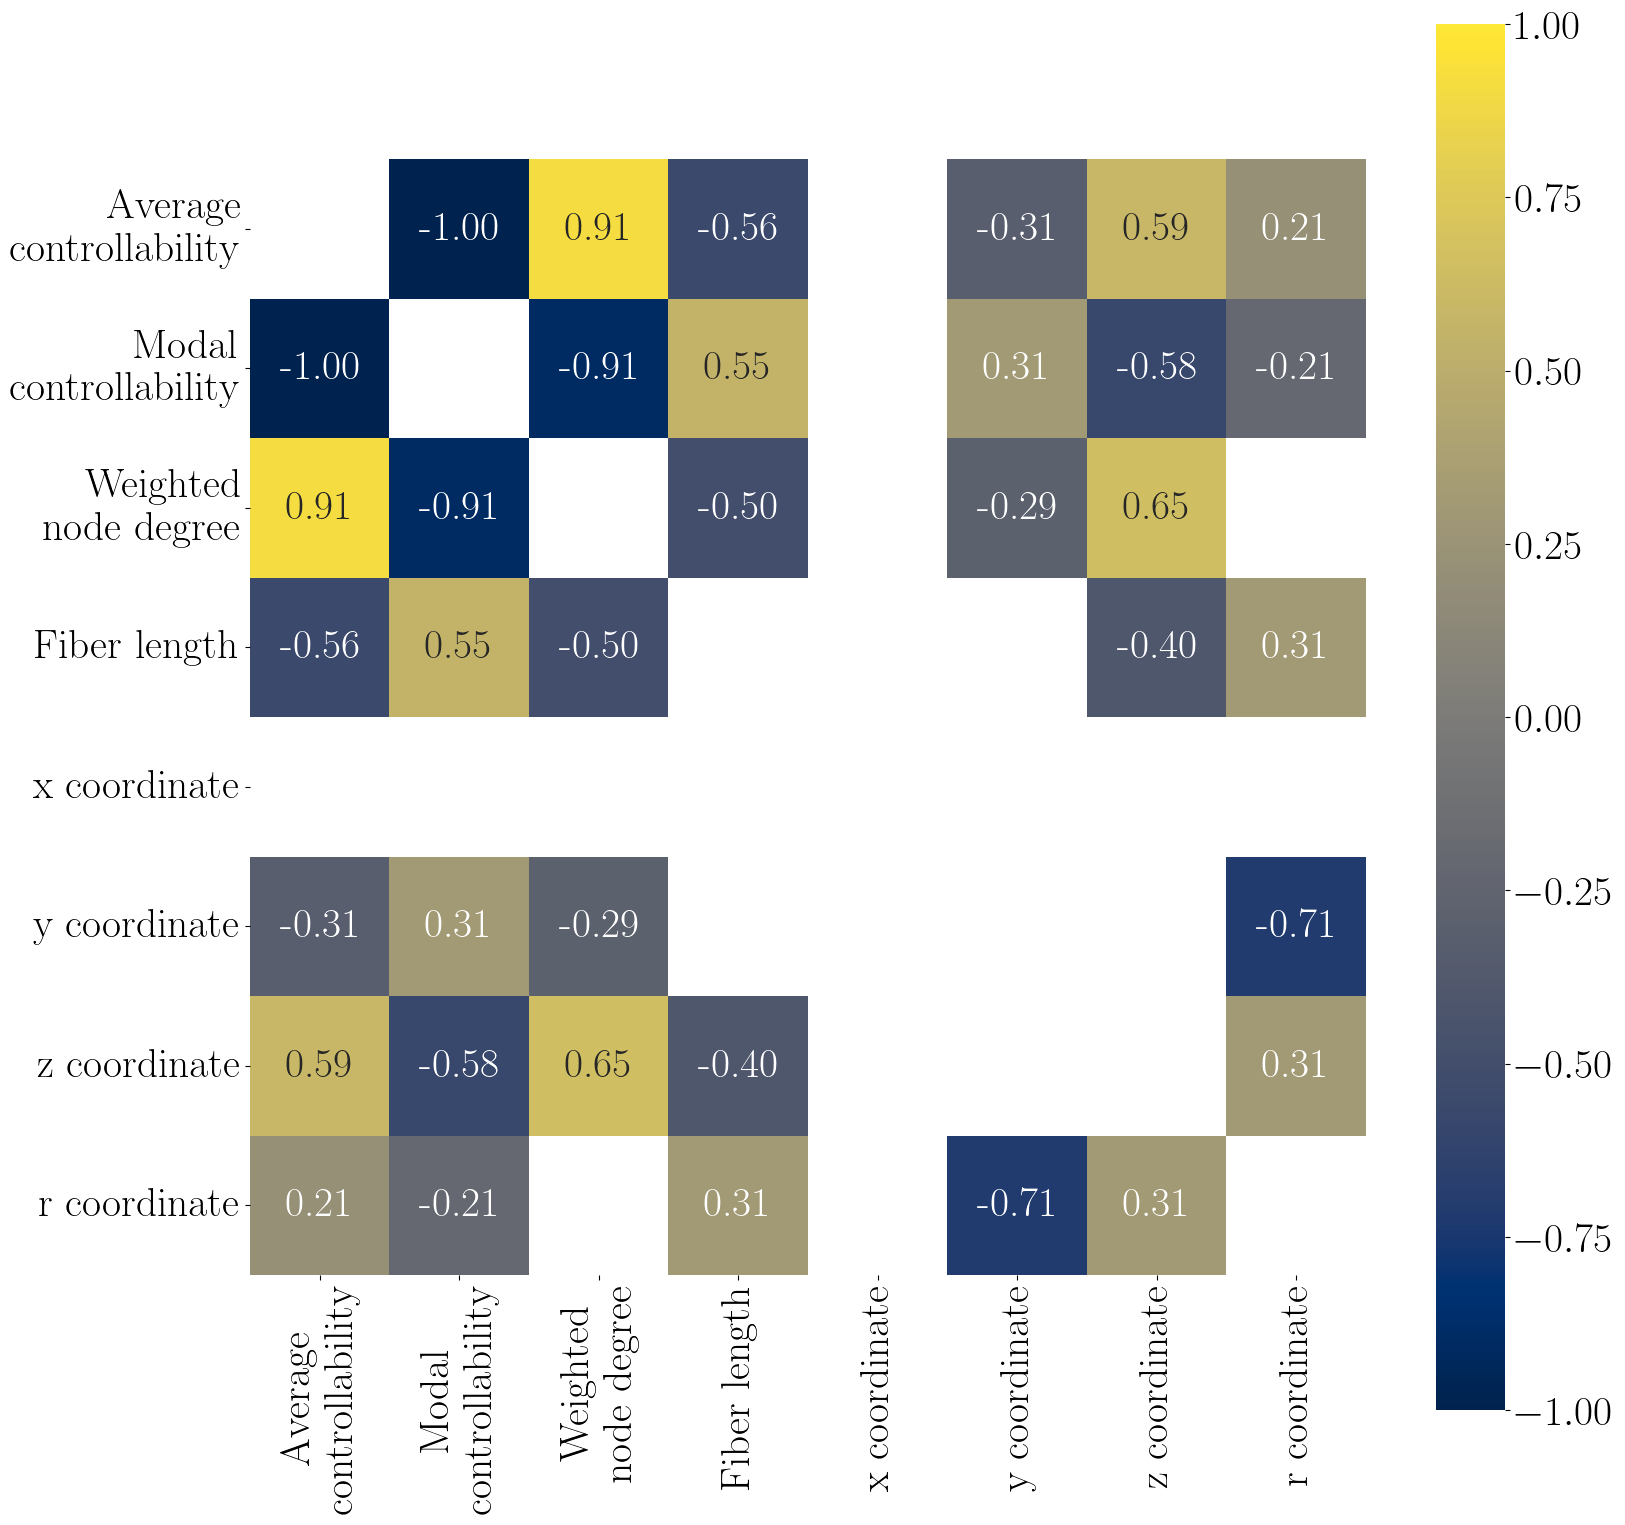

In [41]:
xlabel = ["Average\n controllability", "Modal\n controllability", "Weighted\n node degree", "Fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]

annotations = r_mat_cd_cd.copy()

for ix in range(len(xlabel)):
    annotations[ix, ix] = None

if False:
    plt.figure(figsize=(16,16))
    ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=xlabel, xticklabels=xlabel, vmin=-1, vmax=1)
    ax.set_aspect('equal', adjustable='box')
    plt.savefig(os.path.join(datadir, "cd_cd_0.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

for ix in range(len(xlabel)):
    for iy in range(len(xlabel)):
        if p_mat_cd_cd[ix, iy] >= 0.05:
            annotations[ix, iy] = None

if False:
    plt.figure(figsize=(16,16))
    ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=xlabel, xticklabels=xlabel, vmin=-1, vmax=1)
    ax.set_aspect('equal', adjustable='box')
    plt.savefig(os.path.join(datadir, "cd_cd_1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

for ix in range(len(xlabel)):
    for iy in range(len(xlabel)):
        if np.abs(r_mat_cd_cd[ix, iy]) < 0.0:
            annotations[ix, iy] = None

if True:
    plt.figure(figsize=(18,18))
    ax = sns.heatmap(annotations, annot=True, fmt='.2f', cmap=cmap, yticklabels=xlabel, xticklabels=xlabel, vmin=-1, vmax=1)
    ax.set_aspect('equal', adjustable='box')
    plt.savefig(os.path.join(datadir, "corr_mat_cd.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

annotations = np.delete(annotations, 1, 0)
annotations =  np.delete(annotations, 1, 1)

if False:
    plt.figure(figsize=(16,16))
    ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=np.delete(xlabel, 1, 0), xticklabels=np.delete(xlabel, 1, 0), vmin=-1, vmax=1)
    ax.set_aspect('equal', adjustable='box')
    plt.savefig(os.path.join(datadir, "corr_mat_cd_minM.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

In [349]:
with open(os.path.join(datadir, 'wb.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_var_L2, d1_var_L2, d2_var_L2] = data_read

with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_var_L1, d1_var_L1, d2_var_L1] = data_read

with open(os.path.join(datadir, 'wb_cc.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_cc_L2, d1_cc_L2, d2_cc_L2] = data_read

with open(os.path.join(datadir, 'wb_cc_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_cc_L1, d1_cc_L1, d2_cc_L1] = data_read

dt = 0.1

rng = np.random.default_rng()
method = scipy.stats.PermutationMethod(n_resamples=3. * 1e3, random_state=rng)
cmap = "cividis"

In [350]:
i0, i1 = 60, 450
i0a, i1a = 2780, 3280
i0a0, i1a0 = 3200, 3650
wi = 0
lim = 1e-8

## cost combo / point task / weight / n

peak_times = np.zeros((4, 3, 3, N))
energy = np.zeros((4, 3, 3, N))
input = np.zeros((4, 3, 3, N))
control_times = np.zeros((4, 3, 3, N))

for wi in range(3):

    for n in range(N):
        energy[0,0,wi,n] = np.sum(d0_var_L2["control"][wi][n,0,:])**2 * dt
        input[0,0,wi,n] = np.sum(d0_var_L2["control"][wi][n,0,:]) * dt
        energy[0,1,wi,n] = np.sum(d1_var_L2["control"][wi][n,0,:])**2 * dt
        input[0,1,wi,n] = np.sum(d1_var_L2["control"][wi][n,0,:]) * dt
        energy[0,2,wi,n] = np.sum(d2_var_L2["control"][wi][n,0,:])**2 * dt
        input[0,2,wi,n] = np.sum(d2_var_L2["control"][wi][n,0,:]) * dt

        energy[1,0,wi,n] = np.sum(d0_var_L1["control"][wi][n,0,:])**2 * dt
        input[1,0,wi,n] = np.sum(d0_var_L1["control"][wi][n,0,:]) * dt
        energy[1,1,wi,n] = np.sum(d1_var_L1["control"][wi][n,0,:])**2 * dt
        input[1,1,wi,n] = np.sum(d1_var_L1["control"][wi][n,0,:]) * dt
        energy[1,2,wi,n] = np.sum(d2_var_L1["control"][wi][n,0,:])**2 * dt
        input[1,2,wi,n] = np.sum(d2_var_L1["control"][wi][n,0,:]) * dt

        energy[2,0,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:])**2 * dt
        input[2,0,wi,n] = np.sum(d0_cc_L2["control"][wi][n,0,:]) * dt
        energy[2,1,wi,n] = np.sum(d1_cc_L2["control"][wi][n,0,:])**2 * dt
        input[2,1,wi,n] = np.sum(d1_cc_L2["control"][wi][n,0,:]) * dt
        energy[2,2,wi,n] = np.sum(d2_cc_L2["control"][wi][n,0,:])**2 * dt
        input[2,2,wi,n] = np.sum(d2_cc_L2["control"][wi][n,0,:]) * dt

        energy[3,0,wi,n] = np.sum(d0_cc_L1["control"][wi][n,0,:])**2 * dt
        input[3,0,wi,n] = np.sum(d0_cc_L1["control"][wi][n,0,:]) * dt
        energy[3,1,wi,n] = np.sum(d1_cc_L1["control"][wi][n,0,:])**2 * dt
        input[3,1,wi,n] = np.sum(d1_cc_L1["control"][wi][n,0,:]) * dt
        energy[3,2,wi,n] = np.sum(d2_cc_L1["control"][wi][n,0,:])**2 * dt
        input[3,2,wi,n] = np.sum(d2_cc_L1["control"][wi][n,0,:]) * dt

    for n in range(N):
        peak_times[0,0,wi,n] = scipy.signal.find_peaks(d0_var_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[0,2,wi,n] = scipy.signal.find_peaks(d2_var_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[1,0,wi,n] = scipy.signal.find_peaks(d0_var_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[1,2,wi,n] = scipy.signal.find_peaks(d2_var_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[2,0,wi,n] = scipy.signal.find_peaks(d0_cc_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[2,2,wi,n] = scipy.signal.find_peaks(d2_cc_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[3,0,wi,n] = scipy.signal.find_peaks(d0_cc_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[3,2,wi,n] = scipy.signal.find_peaks(d2_cc_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]

    peak_times[0,0,wi,:] -= np.amin(peak_times[0,0,wi,:])
    peak_times[0,2,wi,:] -= np.amin(peak_times[0,2,wi,:])
    peak_times[1,0,wi,:] -= np.amin(peak_times[1,0,wi,:])
    peak_times[1,2,wi,:] -= np.amin(peak_times[1,2,wi,:])
    peak_times[2,0,wi,:] -= np.amin(peak_times[2,0,wi,:])
    peak_times[2,2,wi,:] -= np.amin(peak_times[2,2,wi,:])
    peak_times[3,0,wi,:] -= np.amin(peak_times[3,0,wi,:])
    peak_times[3,2,wi,:] -= np.amin(peak_times[3,2,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_var_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d0_var_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[0,0,wi,n] = peaktime
    control_times[0,0,wi,:] -= np.median(control_times[0,0,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_var_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d2_var_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[0,2,wi,n] = peaktime
    control_times[0,2,wi,:] -= np.median(control_times[0,2,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_var_L1["control"][wi][n,0,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d0_var_L1["control"][wi][n,0,i0+peaktime_array]))]
            control_times[1,0,wi,n] = peaktime

    valvec = []
    for n in range(N):
        if control_times[1,0,wi,n] != 0:    
            valvec.append(control_times[1,0,wi,n])
    for n in range(N):
        if control_times[1,0,wi,n] != 0:
            control_times[1,0,wi,n] -= np.median(valvec)
    
    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_var_L1["control"][wi][n,0,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d2_var_L1["control"][wi][n,0,i0+peaktime_array]))]
            if np.abs(d2_var_L1["control"][wi][n,0,peaktime]) > lim:
                control_times[1,2,wi,n] = peaktime

    valvec = []
    for n in range(N):
        if control_times[1,2,wi,n] != 0:
            valvec.append(control_times[1,0,wi,n])
    for n in range(N):
        if control_times[1,2,wi,n] != 0:
            control_times[1,2,wi,n] -= np.median(valvec)

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_cc_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d0_cc_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[2,0,wi,n] = peaktime
    control_times[2,0,wi,:] -= np.median(control_times[2,0,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_cc_L2["control"][wi][n,0,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d2_cc_L2["control"][wi][n,0,i0+peaktime_array]))]
        control_times[2,2,wi,n] = peaktime
    
    control_times[2,2,wi,:] -= np.median(control_times[2,2,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_cc_L1["control"][wi][n,0,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d0_cc_L1["control"][wi][n,0,i0+peaktime_array]))]
            control_times[3,0,wi,n] = peaktime

    minct = np.amin(control_times[3,0,wi,:])
    for n in range(N):
        if control_times[3,0,wi,n] != 0:    
            control_times[3,0,wi,n] -= minct

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_cc_L1["control"][wi][n,0,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d2_cc_L1["control"][wi][n,0,i0+peaktime_array]))]
            control_times[3,2,wi,n] = peaktime

    minct = np.amin(control_times[3,2,wi,:])
    for n in range(N):
        if control_times[3,2,wi,n] != 0:    
            control_times[3,2,wi,n] -= minct




    

    sumact = np.sum(d1_var_L2["state"][wi][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)

    for n in range(N):
        peak_times[0,1,wi,n] = scipy.signal.find_peaks(d1_var_L2["state"][wi][n,0,:minact], height=0.7)[0][-1]
    peak_times[0,1,wi,:] -= np.amin(peak_times[0,1,wi,:])

    enmax_ind = np.argmax(energy[0,1,wi,:])
    ia0_= scipy.signal.find_peaks(d1_var_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_var_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_var_L2["control"][wi][n,0,ia0_:ia1_]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d1_var_L2["control"][wi][n,0,ia0_+peaktime_array]))]
        control_times[0,1,wi,n] = peaktime
    control_times[0,1,wi,enmax_ind] = 0.


    sumact = np.sum(d1_var_L1["state"][wi][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)

    for n in range(N):
        peak_times[1,1,wi,n] = scipy.signal.find_peaks(d1_var_L1["state"][wi][n,0,:minact], height=0.7)[0][-1]
    peak_times[1,1,wi,:] -= np.amin(peak_times[1,1,wi,:])

    enmax_ind = 71
    ia0_ = scipy.signal.find_peaks(d1_var_L1["state"][wi][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_var_L1["state"][wi][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_var_L1["control"][wi][n,0,ia0_:ia1_]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d1_var_L1["control"][wi][n,0,ia0_+peaktime_array]))]
            control_times[1,1,wi,n] = peaktime
    control_times[1,1,wi,enmax_ind] = 0.

    
    sumact = np.sum(d1_cc_L2["state"][wi][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)
    

    for n in range(N):
        peak_times[2,1,wi,n] = scipy.signal.find_peaks(d1_cc_L2["state"][wi][n,0,:minact], height=0.7)[0][-1]
    peak_times[2,1,wi,:] -= np.amin(peak_times[2,1,wi,:])

    enmax_ind = np.argmax(energy[2,1,wi,:])
    ia0_ = scipy.signal.find_peaks(d1_cc_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_cc_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_cc_L2["control"][wi][n,0,ia0_:ia1_]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d1_cc_L2["control"][wi][n,0,ia0_+peaktime_array]))]
        control_times[2,1,wi,n] = peaktime
    control_times[2,1,wi,enmax_ind] = 0.



    sumact = np.sum(d1_cc_L1["state"][wi][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)

    for n in range(N):
        peak_times[3,1,wi,n] = scipy.signal.find_peaks(d1_cc_L1["state"][wi][n,0,:minact], height=0.7)[0][-1]
    peak_times[3,1,wi,:] -= np.amin(peak_times[3,1,wi,:])

    enmax_ind = 9
    ia0_ = scipy.signal.find_peaks(d1_cc_L1["state"][wi][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_cc_L1["state"][wi][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_cc_L1["control"][wi][n,0,ia0_:ia1_]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d1_cc_L1["control"][wi][n,0,ia0_+peaktime_array]))]
            control_times[3,1,wi,n] = peaktime
    control_times[3,1,wi,enmax_ind] = 0.

peak_times *= dt
control_times *= dt

In [351]:
def get_period(x):
    peaks = scipy.signal.find_peaks(x, height=0.7)[0]
    pe_list = []

    for pi in range(len(peaks)-1):
        pe_list.append(peaks[pi+1] - peaks[pi])

    return np.mean(pe_list)

phases = np.zeros((4, 3, 3, N, 2))

period_b = []
period_a = []
period_c = []

print(d0_var_L2["state_uncontrolled"].shape)
for n in range(N):
    period_b.append(get_period(d0_var_L2["state_uncontrolled"][n,0,:]))
    period_a.append(get_period(d2_var_L2["state_uncontrolled"][n,0,:]))
    period_c.append(get_period(d1_var_L2["state_uncontrolled"][n,0,:]))

period_b = np.mean(period_b)
period_a = np.mean(period_a)
period_c = np.mean(period_c)

for task, d in zip([0,2], [d0_var_L2, d0_cc_L2]):
    for wi in range(3):

        for n in range(N):
            phs = []
            for tpind in range(1):
            
                tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                period = tps1 - tps0

                if period == 0: continue

                inittime = tps0+50
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps1+1]), height=0.001)[0]

                if len(cpeaktime) == 0:
                    print("empty 0")
                    continue

                peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]
                phs.append(2. * np.pi * peaktime/period_b)

            if len(phs) > 0:
                phases[task,0,wi, n, 0] = np.mean(phs)
                phases[task,0,wi, n, 1] = np.std(phs)


for task, d in zip([0,2], [d2_var_L2, d2_cc_L2]):
    for wi in range(3):

        for n in range(N):
            phs = []
            for tpind in range(1):
            
                tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                period = tps1 - tps0

                if period == 0: continue

                inittime = tps0+50
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps1+1]), height=0.001)[0]

                if len(cpeaktime) == 0:
                    print("empty 2")
                    continue

                peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]
                phs.append(2. * np.pi * peaktime/period_a)

            if len(phs) > 0:
                phases[task,2,wi, n, 0] = np.mean(phs)
                phases[task,2,wi, n, 1] = np.std(phs)


for task, d in zip([0,2], [d1_var_L2, d1_cc_L2]):
    for wi in range(3):

        for n in range(N):
            phs = []
            for tpind in range(5, 6, 1):
            
                tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                period = tps1 - tps0

                if period == 0: continue

                inittime = tps0
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps1+1]), height=0.001)[0]

                if len(cpeaktime) == 0:
                    print("empty 1")
                    continue

                peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]
                phs.append(2. * np.pi * peaktime/period_c)

            if len(phs) > 0:
                phases[task,1,wi, n, 0] = np.mean(phs)
                phases[task,1,wi, n, 1] = np.std(phs)


(100, 2, 4000)
empty 0
empty 0
empty 0
empty 0
empty 1
empty 1
empty 1
empty 1
empty 1


205 722


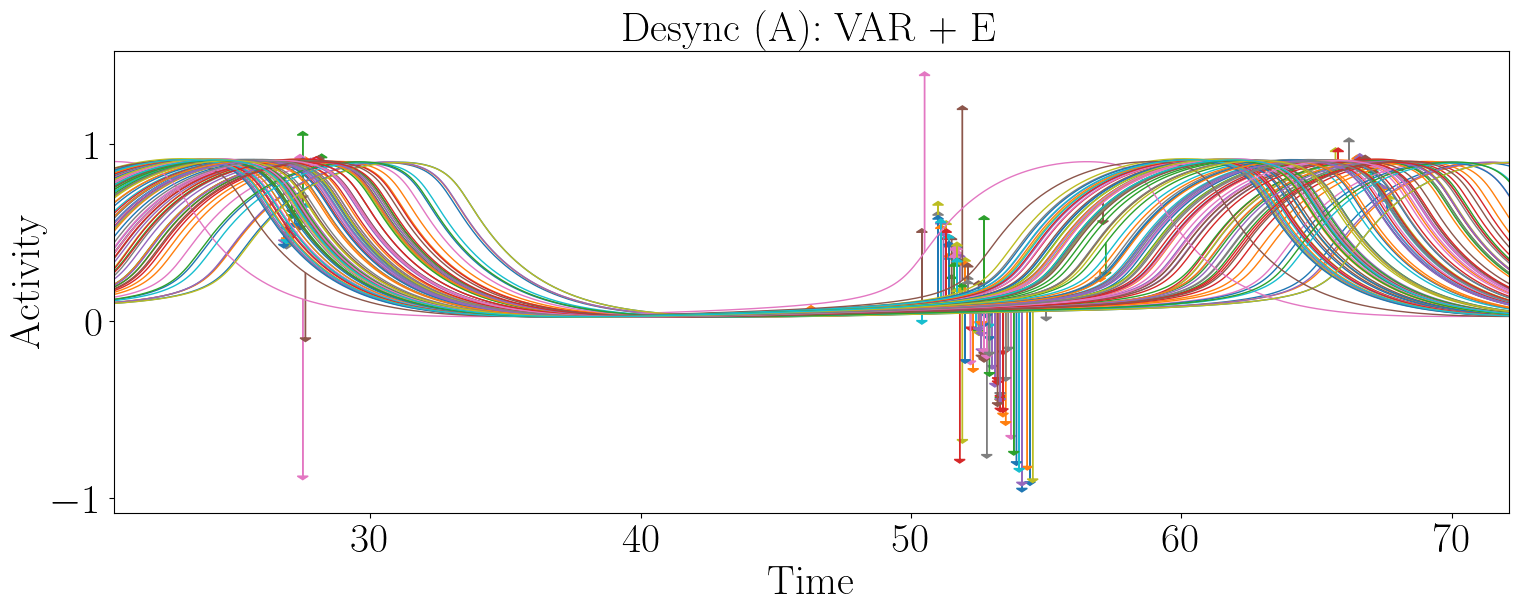

236 701


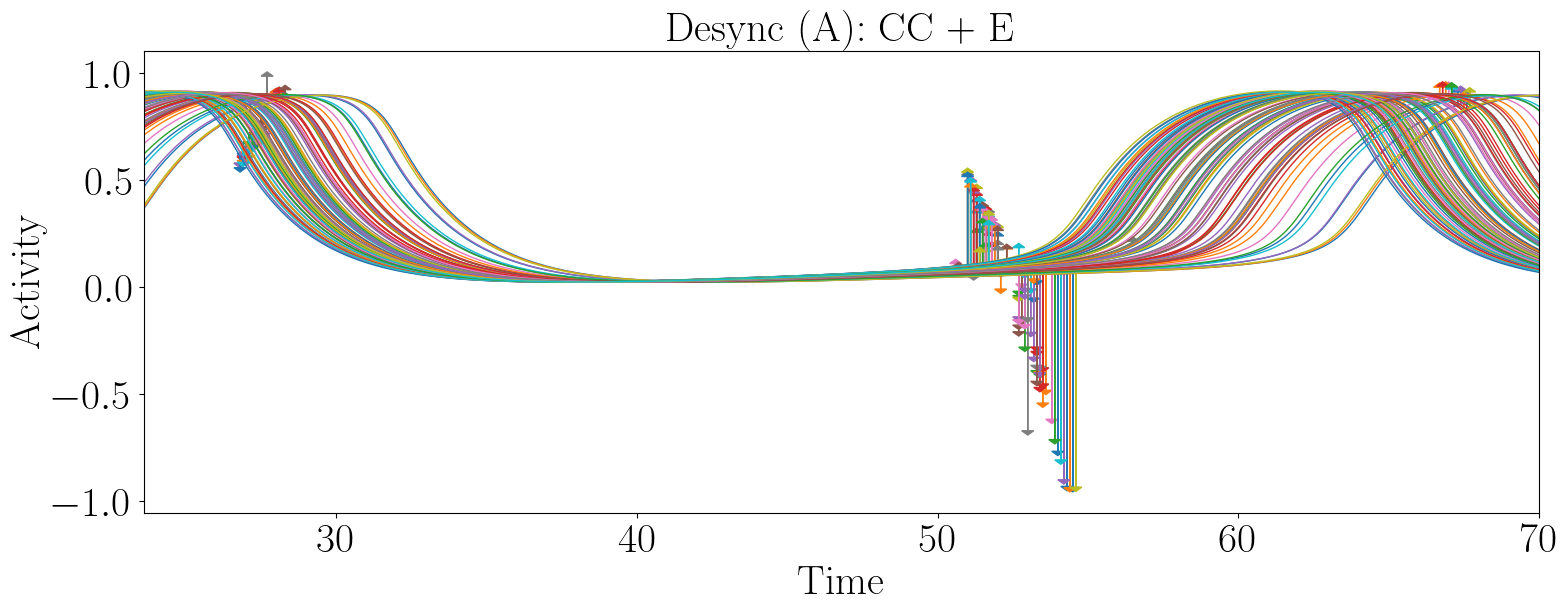

197 823


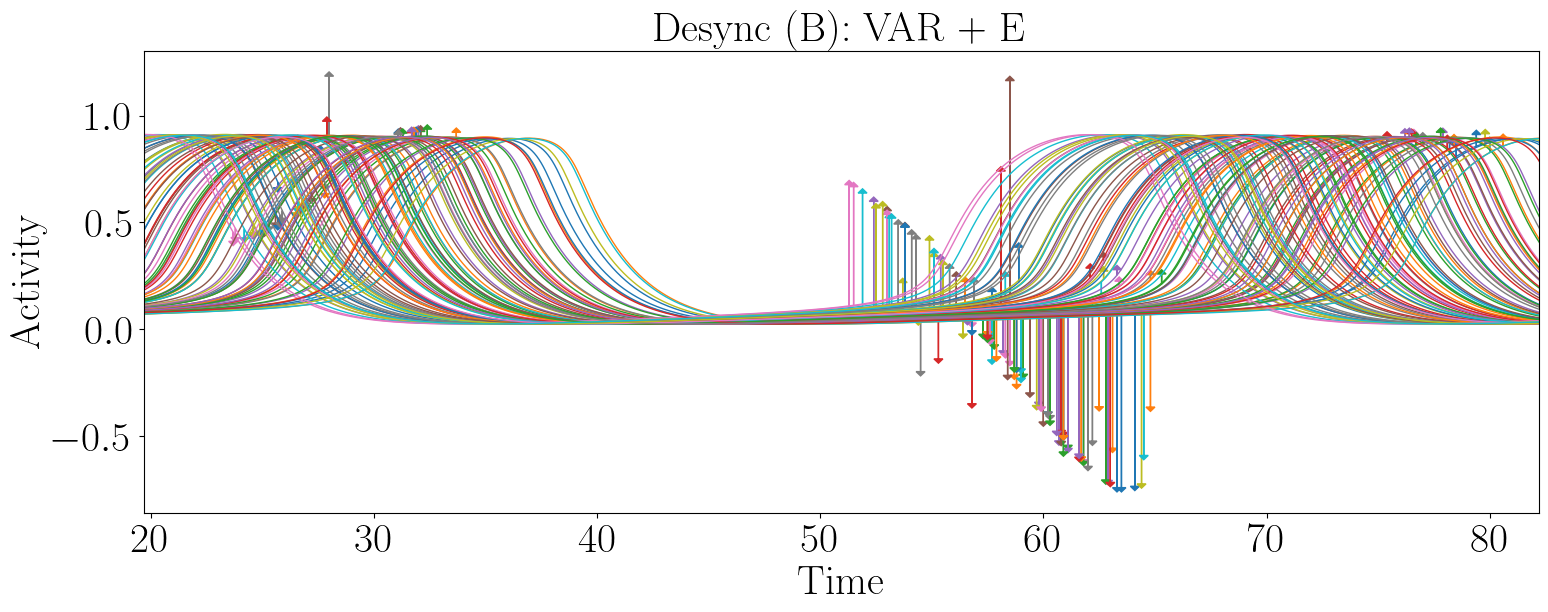

202 829


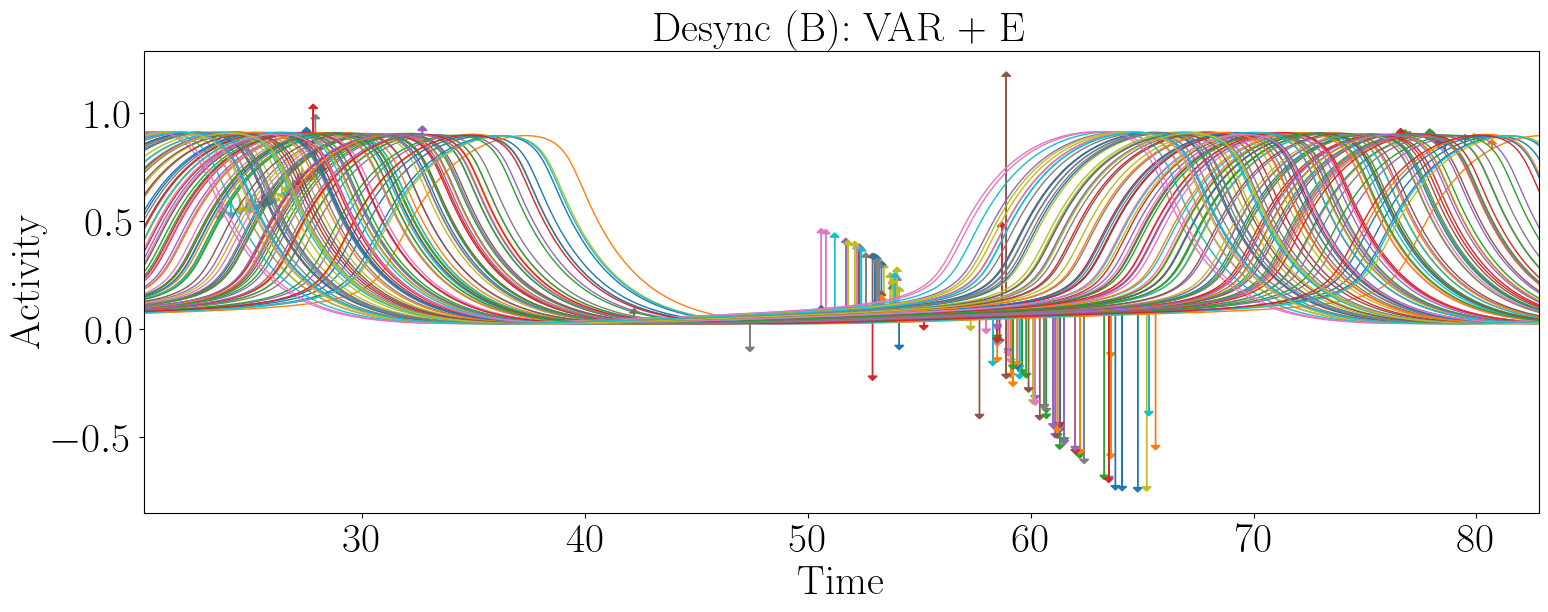

3135 3978


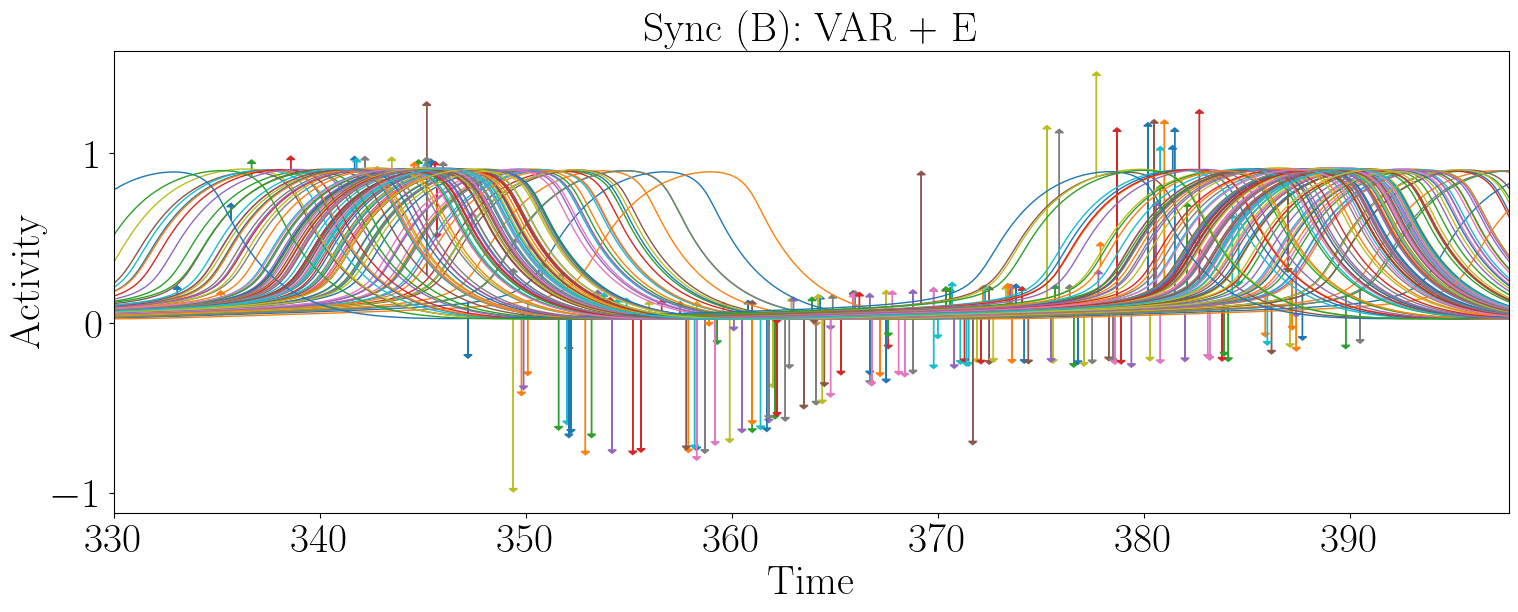

3349 3943


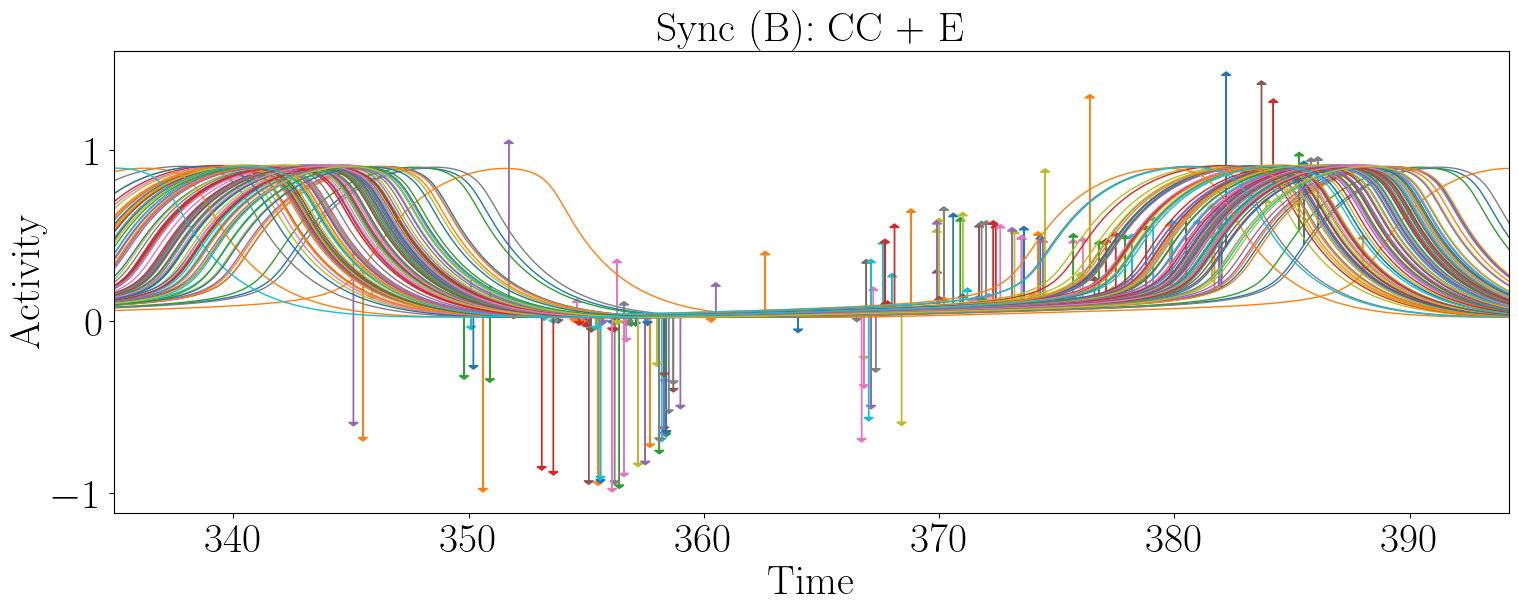

In [14]:
def plot_snippet(wi, d, lim, title, filename, maxarrowlength, factor, last = False):
    fig = plt.figure(figsize=(18,6))
    ax = fig.add_subplot(111)

    time = np.arange(0., 400.+dt, dt)

    p0min = 10000
    p1max = 0
    
    for n in range(N):

        line = ax.plot(time, d["state"][wi][n,0,:])
        col = line[0].get_color()        
        
        if last:
            [i0, i1] = scipy.signal.find_peaks(d["state"][wi][n,0,:])[0][-2:]
        else:
            [i0, i1] = scipy.signal.find_peaks(d["state"][wi][n,0,:])[0][:2]

        if i0 < p0min:
            p0min = i0

        if i1 > p1max:
            p1max = i1

        peaktime_array = scipy.signal.find_peaks(d["control"][wi][n,0,i0:i1+1])[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(d["control"][wi][n,0,i0+peaktime_array])]
            if np.abs(d["control"][wi][n,0,i0+peaktime]) > lim:
                arrowlength = min(maxarrowlength, factor*d["control"][wi][n,0,i0+peaktime])
                plt.arrow((i0+peaktime)*dt, d["state"][wi][n,0,i0+peaktime], 0, arrowlength, head_width=0.4, head_length=0.02, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d["control"][wi][n,0,i0:i1])[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(-d["control"][wi][n,0,i0+peaktime_array])]
            if np.abs(d["control"][wi][n,0,i0+peaktime]) > lim:
                arrowlength = max(-maxarrowlength, factor*d["control"][wi][n,0,i0+peaktime])
                plt.arrow((i0+peaktime)*dt, d["state"][wi][n,0,i0+peaktime], 0, arrowlength, head_width=0.4, head_length=0.02, length_includes_head=False, color=col)


    print(p0min, p1max)
    if last:
        p0min = max(p0min, 3300)
    ax.set_xlim(p0min*dt, (p1max-1)*dt)

    ax.set_title(title)
    ax.set_ylabel("Activity")
    ax.set_xlabel("Time")
    plt.savefig(os.path.join(datadir, filename), bbox_inches='tight', dpi=300)
    plt.show()

wi = 1
lim = 1. * 1e-3

d = d2_var_L2.copy()
plot_snippet(wi, d, lim, "Desync (A): VAR + E", "phases_A_VAR_E.jpg", 1., 10.)

d = d2_cc_L2.copy()
plot_snippet(wi, d, lim, "Desync (A): CC + E", "phases_A_CC_E.jpg", 1., 10.)

d = d0_var_L2.copy()
plot_snippet(wi, d, lim, "Desync (B): VAR + E", "phases_B_VAR_E.jpg", 1., 20.)

d = d0_cc_L2.copy()
plot_snippet(wi, d, lim, "Desync (B): VAR + E", "phases_B_VAR_E.jpg", 1., 20.)

d = d1_var_L2.copy()
plot_snippet(0, d, lim, "Sync (B): VAR + E", "phases_syncB_VAR_E.jpg", 1., 20., last=True)

d = d1_cc_L2.copy()
plot_snippet(2, d, lim, "Sync (B): CC + E", "phases_syncB_CC_E.jpg", 1., 20., last=True)

In [288]:
r, p = scipy.stats.pearsonr(peak_times[0,2,0,:], peak_times[0,0,0,:], method=method)
print(r, p)

0.7456240266574911 0.0006664445184938354


/tmp/ipykernel_475329/4099760732.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('tab10')


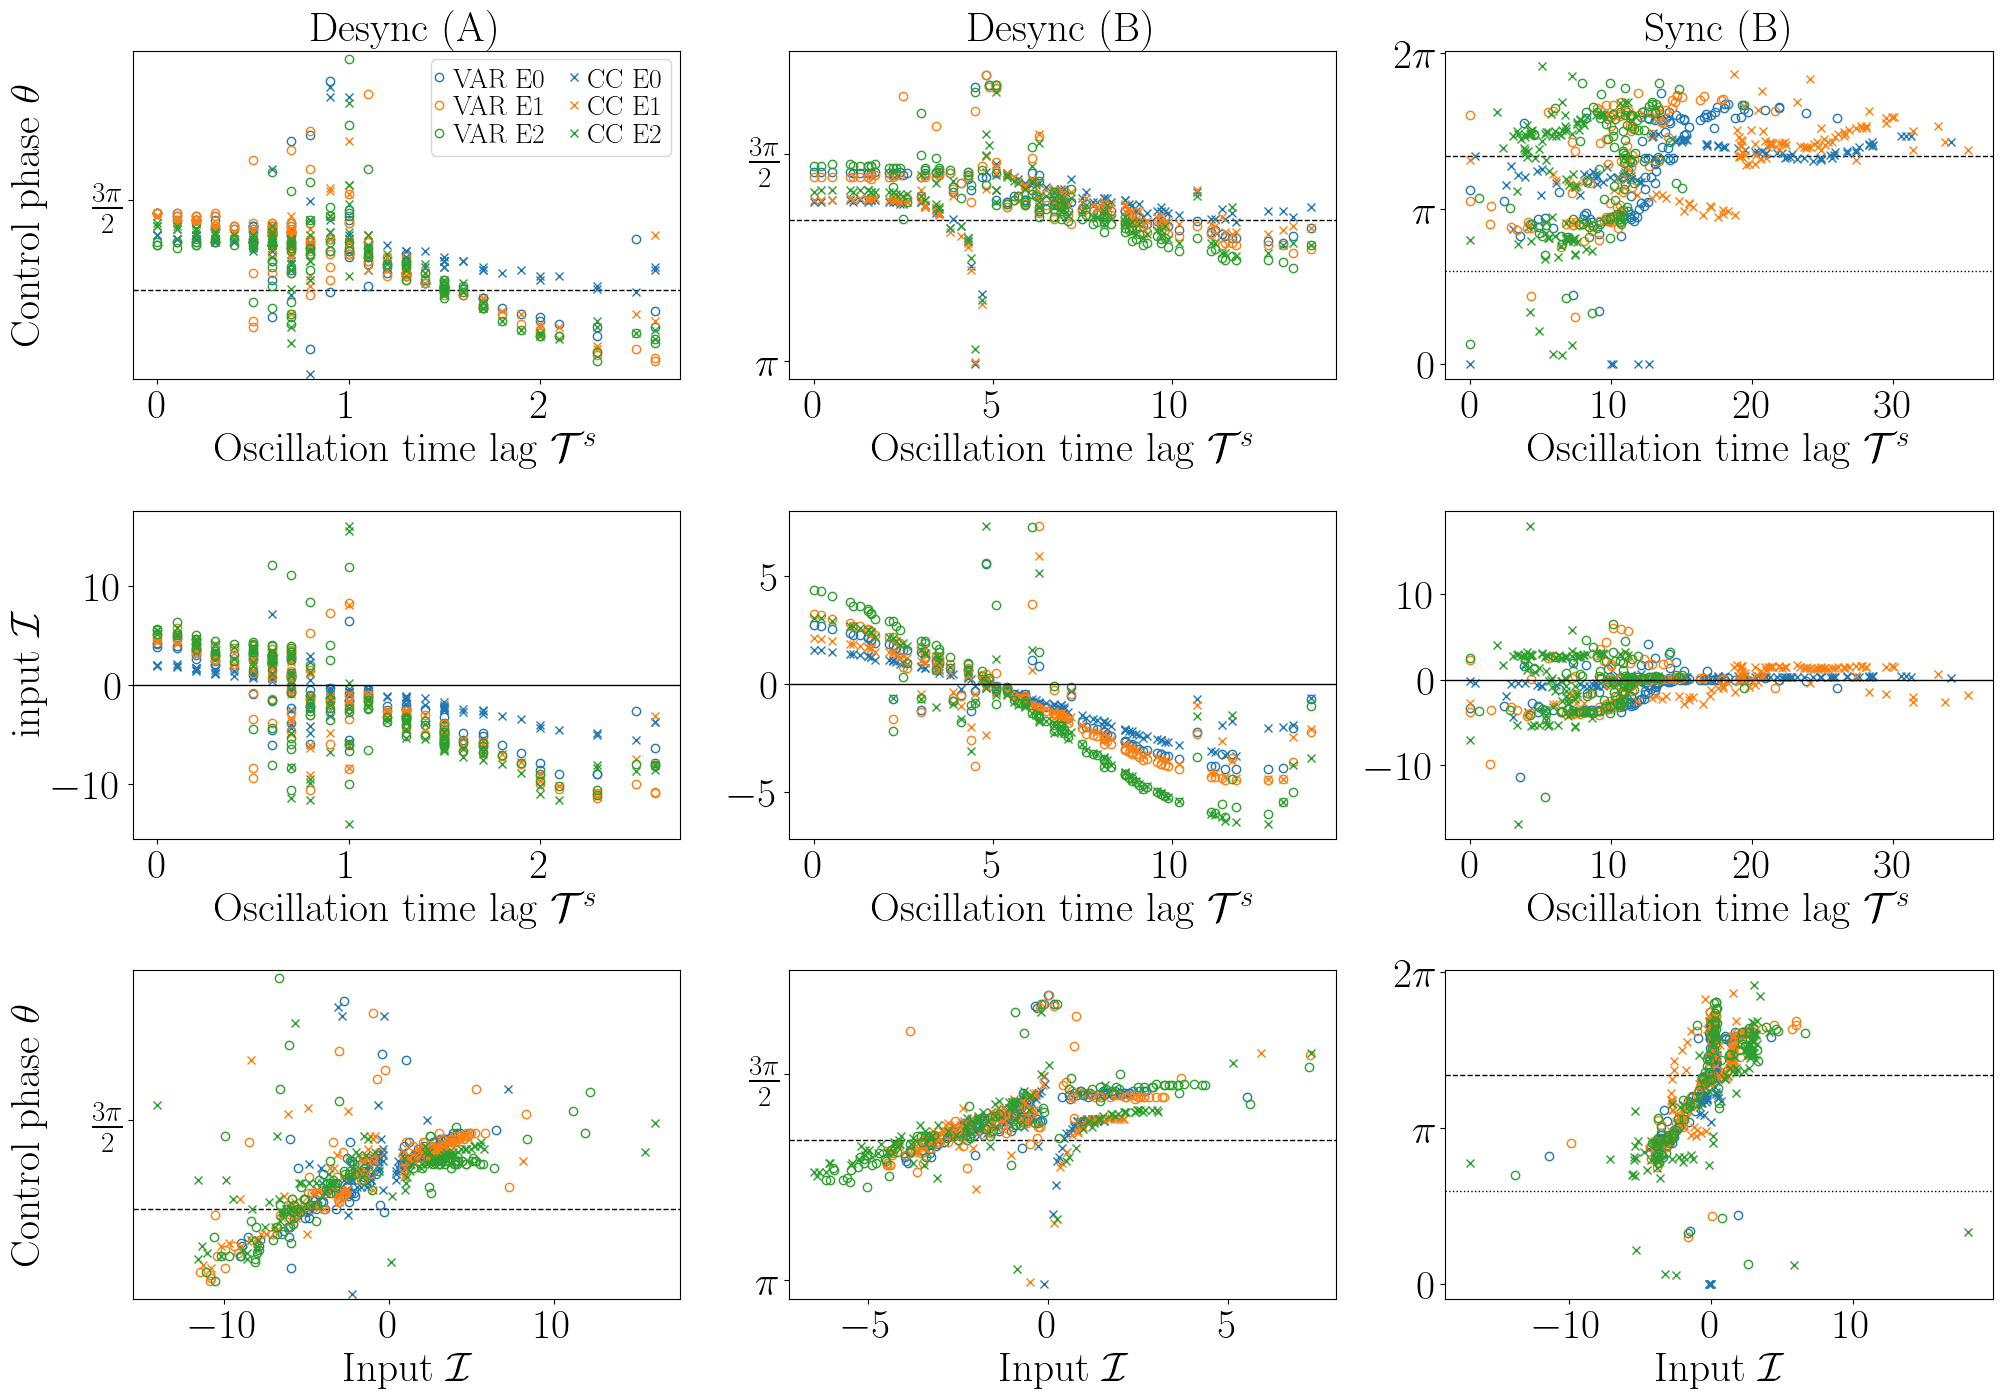

In [481]:
xlabel = r"Oscillation time lag $\mathcal{T}^s$"
ylabel = [r"Control phase $\mathcal{\theta}$", r"input $\mathcal{I}$", r"Control phase $\mathcal{\theta}$"]
titles = ["Desync (A)", "Desync (B)", "Sync (B)"]

#### cost comb // point // weight // n

colmap = mpl.cm.get_cmap('tab10')
marker= ["o", "x"]
mew = 1

x_array = peak_times[0,:]

fig, ax = plt.subplots(len(ylabel), 3, figsize=(24,16))

for wi in range(3):
    #ax[0,0].plot(peak_times[0, 2, wi, :], control_times[0, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi*0.1), linestyle="none")
    ax[0,0].errorbar(peak_times[0, 2, wi, :], phases[0, 2, wi, :, 0], yerr=phases[0, 2, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[1,0].plot(peak_times[0, 2, wi, :], input[0, 2, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[2,0].errorbar(input[0, 2, wi, :], phases[0, 2, wi, :, 0], yerr=phases[0, 2, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")

    #ax[0,1].plot(peak_times[2, 2, wi, :], control_times[2, 2, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi*0.1), linestyle="none")
    ax[0,0].errorbar(peak_times[2, 2, wi, :], phases[2, 2, wi, :, 0], yerr=phases[2, 2, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[1,0].plot(peak_times[2, 2, wi, :], input[2, 2, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[2,0].errorbar(input[2, 2, wi, :], phases[2, 2, wi, :, 0], yerr=phases[2, 2, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    
    #ax[0,2].plot(peak_times[0, 0, wi, :], control_times[0, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi*0.1), linestyle="none")
    ax[0,1].errorbar(peak_times[0, 0, wi, :], phases[0, 0, wi, :, 0], yerr=phases[0, 0, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[1,1].plot(peak_times[0, 0, wi, :], input[0, 0, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[2,1].errorbar(input[0, 0, wi, :], phases[0, 0, wi, :, 0], yerr=phases[0, 0, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    
    #ax[0,3].plot(peak_times[2, 0, wi, :], control_times[2, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi*0.1), linestyle="none")
    ax[0,1].errorbar(peak_times[2, 0, wi, :], phases[2, 0, wi, :, 0], yerr=phases[2, 0, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[1,1].plot(peak_times[2, 0, wi, :], input[2, 0, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[2,1].errorbar(input[2, 0, wi, :], phases[2, 0, wi, :, 0], yerr=phases[2, 0, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")

    #ax[0,2].plot(peak_times[0, 0, wi, :], control_times[0, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi*0.1), linestyle="none")
    ax[0,2].errorbar(peak_times[0, 1, wi, :], phases[0, 1, wi, :, 0], yerr=phases[0, 1, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[1,2].plot(peak_times[0, 1, wi, :], input[0, 1, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[2,2].errorbar(input[0, 1, wi, :], phases[0, 1, wi, :, 0], yerr=phases[0, 1, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    
    #ax[0,3].plot(peak_times[2, 0, wi, :], control_times[2, 0, wi, :], marker=marker[wi], markerfacecolor="none", markeredgewidth=2, color=colmap(wi*0.1), linestyle="none")
    ax[0,2].errorbar(peak_times[2, 1, wi, :], phases[2, 1, wi, :, 0], yerr=phases[2, 1, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[1,2].plot(peak_times[2, 1, wi, :], input[2, 1, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[2,2].errorbar(input[2, 1, wi, :], phases[2, 1, wi, :, 0], yerr=phases[2, 1, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")

ax[0,0].set_ylabel(ylabel[0])
ax[1,0].set_ylabel(ylabel[1])
ax[2,0].set_ylabel(ylabel[2])

for ix in [0,2]:
    ax[ix,0].set_yticks([np.pi, 1.5*np.pi, 2.*np.pi])
    ax[ix,0].set_yticklabels([r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
    ax[ix,0].set_ylim([1.2*np.pi, 1.75*np.pi])
    ax[ix,1].set_yticks([np.pi, 1.5*np.pi, 2.*np.pi])
    ax[ix,1].set_yticklabels([r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
    ax[ix,1].set_ylim([3, 1.75*np.pi])

    ax[ix,2].set_yticks([0., np.pi, 2.*np.pi])
    ax[ix,2].set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"])

    ax[ix,0].axhline(y=1.35*np.pi, color='k', linestyle="--")
    ax[ix,1].axhline(y=1.34*np.pi, color='k', linestyle="--")
    ax[ix,2].axhline(y=1.34*np.pi, color='k', linestyle="--")
    ax[ix,2].axhline(y=0.6*np.pi, color='k', linestyle=":")

for ix in range(3):
    ax[0,ix].set_title(titles[ix])
    ax[0,ix].set_xlabel(xlabel)
    ax[1,ix].axhline(y=0, color='k')
    ax[1,ix].set_xlabel(xlabel)

    ax[2,ix].set_xlabel(r"Input $\mathcal{I}$")


legend_elements = [Line2D([0], [0], linestyle="none", color=colmap(0), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E0'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.1), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E1'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.2), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E2'),
                   Line2D([0], [0], linestyle="none", color=colmap(0), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E0'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.1), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E1'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.2), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E2'),
                   ]

ax[0,0].legend(fontsize=20, handles=legend_elements, loc="upper right", labelspacing=0.1, handlelength=0., handletextpad=0.5, frameon=True, ncol=2, columnspacing=1, borderpad=0.3, borderaxespad=0.3)

fig.align_ylabels([ax[:]])
plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.2, hspace=0.4)
plt.savefig(os.path.join(datadir, "times_input_all_L2.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [42]:
x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r_coord]
xlabel = ["Average controllability", "Weighted node degree", "Fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]
ylabel = ["Oscillation time lag", "Control phase", "Input", "Energy"]

wi = 1
y_array = [peak_times, phases[:,:,:,:,0], input, energy]

r_mat_sc_cd = np.zeros((len(x_array), len(y_array)))
p_mat_sc_cd = np.zeros((len(x_array), len(y_array)))
tot_count_mat = np.zeros((len(x_array), len(y_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for task in [0,2]:
            for point in [2,0]:
                for wi in range(3):

                    y_arr = y[task, point, wi, :].copy()

                    if iy in [2,3]:
                        y_arr /= np.mean(np.abs(y_arr))

                    #for n in range(N-1, -1, -1):
                        #if np.isnan(y_arr[task, point, wi, n]):
                        #    x_arr = np.delete(x_arr, n, 0)
                        #    y_arr = np.delete(y_arr, n, 3)

                    result = scipy.stats.pearsonr(x, y_arr, method=method)
                    r_val = result.statistic
                    p_val = result.pvalue
                    tot_count_mat[ix,iy] += 1
                    if p_val < 0.05:
                        r_mat_sc_cd[ix, iy] += r_val
                        p_mat_sc_cd[ix, iy] += 1

Average controllability Oscillation time lag
Average controllability Control phase
Average controllability Input
Average controllability Energy
Weighted node degree Oscillation time lag
Weighted node degree Control phase
Weighted node degree Input
Weighted node degree Energy
Fiber length Oscillation time lag
Fiber length Control phase
Fiber length Input
Fiber length Energy
x coordinate Oscillation time lag
x coordinate Control phase
x coordinate Input
x coordinate Energy
y coordinate Oscillation time lag
y coordinate Control phase
y coordinate Input
y coordinate Energy
z coordinate Oscillation time lag
z coordinate Control phase
z coordinate Input
z coordinate Energy
r coordinate Oscillation time lag
r coordinate Control phase
r coordinate Input
r coordinate Energy


[12. 11. 12. 11.]
[12. 12. 12. 12.]


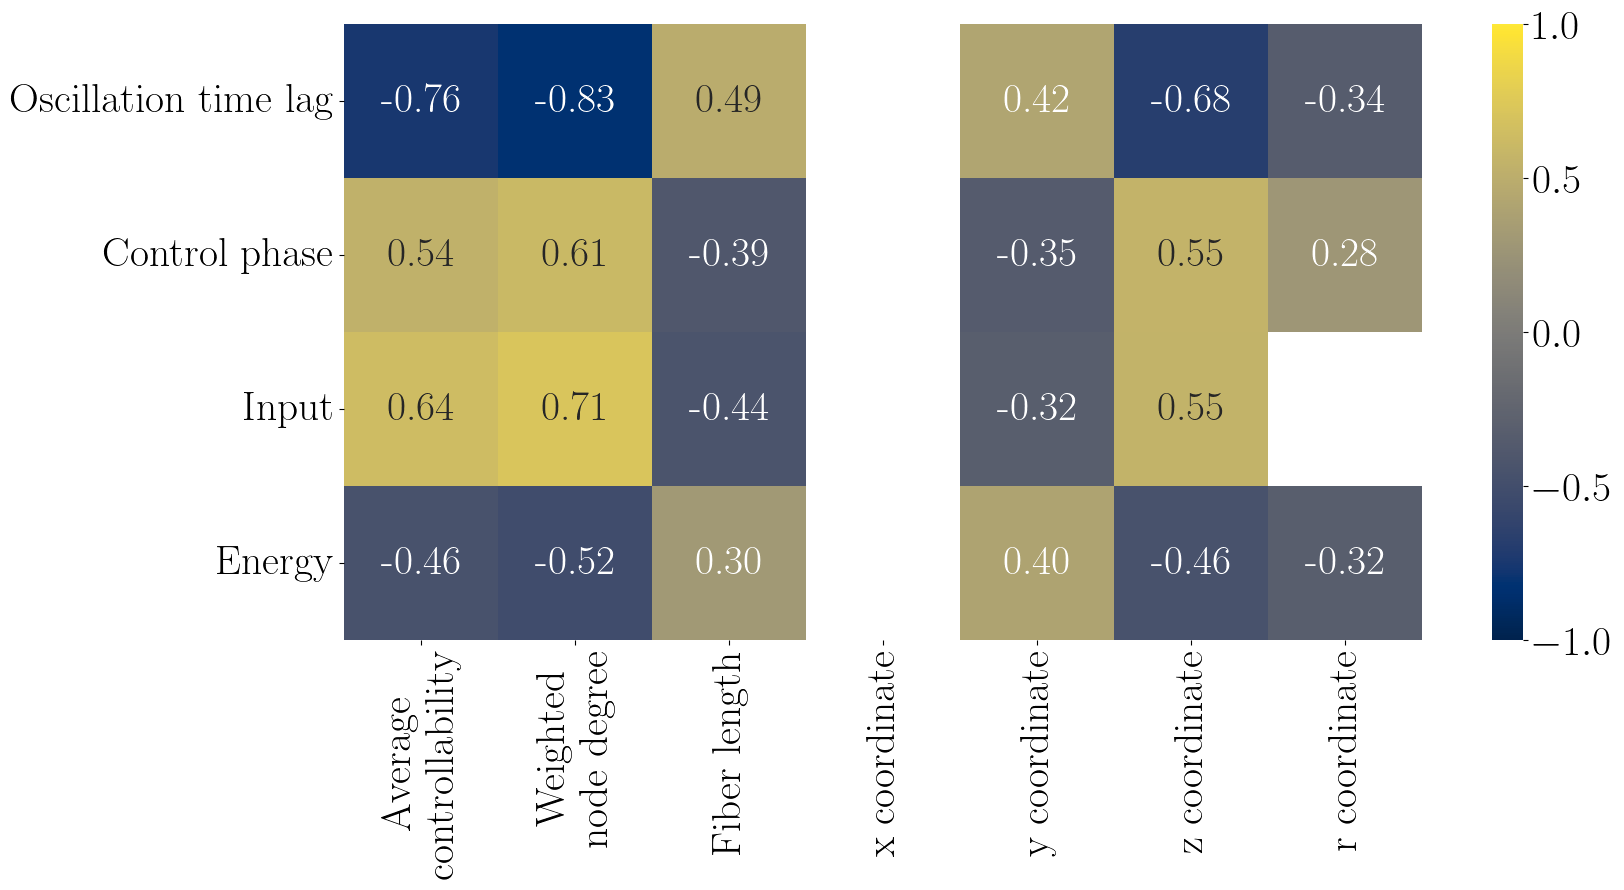

In [43]:
x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r_coord]
xlabel = ["Average\n controllability", "Weighted\n node degree", "Fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate"]
ylabel = ["Oscillation time lag", "Control phase", "Input", "Energy"]

annotations = r_mat_sc_cd.copy()

print(p_mat_sc_cd[1,:])
print(tot_count_mat[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd[ix, iy]/float(tot_count_mat[ix,iy]) <=0.5:
            annotations[ix, iy] = None
        else:
            annotations[ix,iy] /= p_mat_sc_cd[ix, iy]

plt.figure(figsize=(18,8))
ax = sns.heatmap(annotations.T, annot=True, fmt='.2f', cmap=cmap, xticklabels=xlabel, yticklabels=ylabel, vmin=-1, vmax=1)#, annot_kws={"fontweight":"bold"})
#for ind in [[0,0], [2,0], [0,1], [1,1], [2,1], [0,5]]:
#    rect = plt.Rectangle(ind, 1,1, color="red", linewidth=3, fill=False, clip_on=False)
#    ax.add_patch(rect)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90) 
plt.savefig(os.path.join(datadir, "sc_cd_desync.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [44]:
y_array = [peak_times, phases[:,:,:,:,0], input, energy]

r_mat_sc_cd_sync = np.zeros((len(x_array), len(y_array), 3))
p_mat_sc_cd_sync = np.zeros((len(x_array), len(y_array)))
tot_count_mat_sync = np.zeros((len(x_array), len(y_array)))

task, point = 0, 1

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for wi in range(3):

            y_arr = y[task, point, wi, :].copy()

            if iy in [2,3]:
                y_arr /= np.mean(np.abs(y_arr))

            result = scipy.stats.pearsonr(x, y_arr, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            tot_count_mat_sync[ix,iy] += 1
            if p_val < 0.05:
                r_mat_sc_cd_sync[ix, iy, wi] += r_val
                p_mat_sc_cd_sync[ix, iy] += 1

for ix in range(len(x_array)):
    for iy in range(len(y_array)):
        if np.std(r_mat_sc_cd_sync[ix,iy,:])/ np.abs(np.mean(r_mat_sc_cd_sync[ix,iy,:])) > 0.333:
            print("large deviation ", ix, iy)
            p_mat_sc_cd_sync[ix, iy] = 0

Average
 controllability Oscillation time lag
Average
 controllability Control phase
Average
 controllability Input
Average
 controllability Energy
Weighted
 node degree Oscillation time lag
Weighted
 node degree Control phase
Weighted
 node degree Input
Weighted
 node degree Energy
Fiber length Oscillation time lag
Fiber length Control phase
Fiber length Input
Fiber length Energy
x coordinate Oscillation time lag
x coordinate Control phase
x coordinate Input
x coordinate Energy
y coordinate Oscillation time lag
y coordinate Control phase
y coordinate Input
y coordinate Energy
z coordinate Oscillation time lag
z coordinate Control phase
z coordinate Input
z coordinate Energy
r coordinate Oscillation time lag
r coordinate Control phase
r coordinate Input
r coordinate Energy
large deviation  0 2
large deviation  1 3
large deviation  5 0
large deviation  5 1
large deviation  5 2


/tmp/ipykernel_475329/1844876868.py:34: RuntimeWarning: invalid value encountered in scalar divide
  if np.std(r_mat_sc_cd_sync[ix,iy,:])/ np.abs(np.mean(r_mat_sc_cd_sync[ix,iy,:])) > 0.333:


In [45]:
y_array = [peak_times, phases[:,:,:,:,0], input, energy]

r_mat_sc_cd_sync_cc = np.zeros((len(x_array), len(y_array), 3))
p_mat_sc_cd_sync_cc = np.zeros((len(x_array), len(y_array)))
tot_count_mat_sync_cc = np.zeros((len(x_array), len(y_array)))

task, point = 2, 1

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for wi in range(3):

            y_arr = y[task, point, wi, :].copy()

            if iy in [2,3]:
                y_arr /= np.mean(np.abs(y_arr))

            result = scipy.stats.pearsonr(x, y_arr, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            tot_count_mat_sync_cc[ix,iy] += 1
            if p_val < 0.05:
                r_mat_sc_cd_sync_cc[ix, iy, wi] += r_val
                p_mat_sc_cd_sync_cc[ix, iy] += 1

for ix in range(len(x_array)):
    for iy in range(len(y_array)):
        if np.std(r_mat_sc_cd_sync_cc[ix,iy,:])/ np.abs(np.mean(r_mat_sc_cd_sync_cc[ix,iy,:])) > 0.333:
            print("large deviation ", ix, iy)
            p_mat_sc_cd_sync_cc[ix, iy] = 0

Average
 controllability Oscillation time lag
Average
 controllability Control phase
Average
 controllability Input
Average
 controllability Energy
Weighted
 node degree Oscillation time lag
Weighted
 node degree Control phase
Weighted
 node degree Input
Weighted
 node degree Energy
Fiber length Oscillation time lag
Fiber length Control phase
Fiber length Input
Fiber length Energy
x coordinate Oscillation time lag
x coordinate Control phase
x coordinate Input
x coordinate Energy
y coordinate Oscillation time lag
y coordinate Control phase
y coordinate Input
y coordinate Energy
z coordinate Oscillation time lag
z coordinate Control phase
z coordinate Input
z coordinate Energy
r coordinate Oscillation time lag
r coordinate Control phase
r coordinate Input
r coordinate Energy
large deviation  0 2
large deviation  1 1
large deviation  1 2
large deviation  3 0
large deviation  3 1
large deviation  3 3
large deviation  4 0
large deviation  4 2
large deviation  5 2
large deviation  6 0
large 

/tmp/ipykernel_475329/2019883170.py:34: RuntimeWarning: invalid value encountered in scalar divide
  if np.std(r_mat_sc_cd_sync_cc[ix,iy,:])/ np.abs(np.mean(r_mat_sc_cd_sync_cc[ix,iy,:])) > 0.333:


[3. 3. 3. 0.]
[3. 3. 3. 3.]


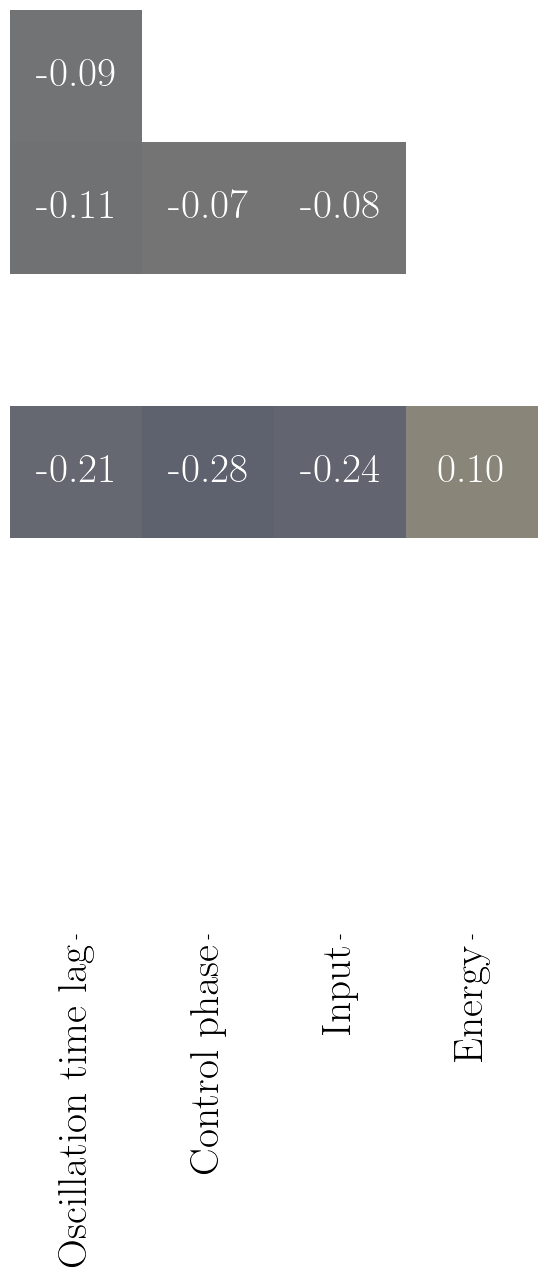

[3. 0. 0. 0.]
[3. 3. 3. 3.]


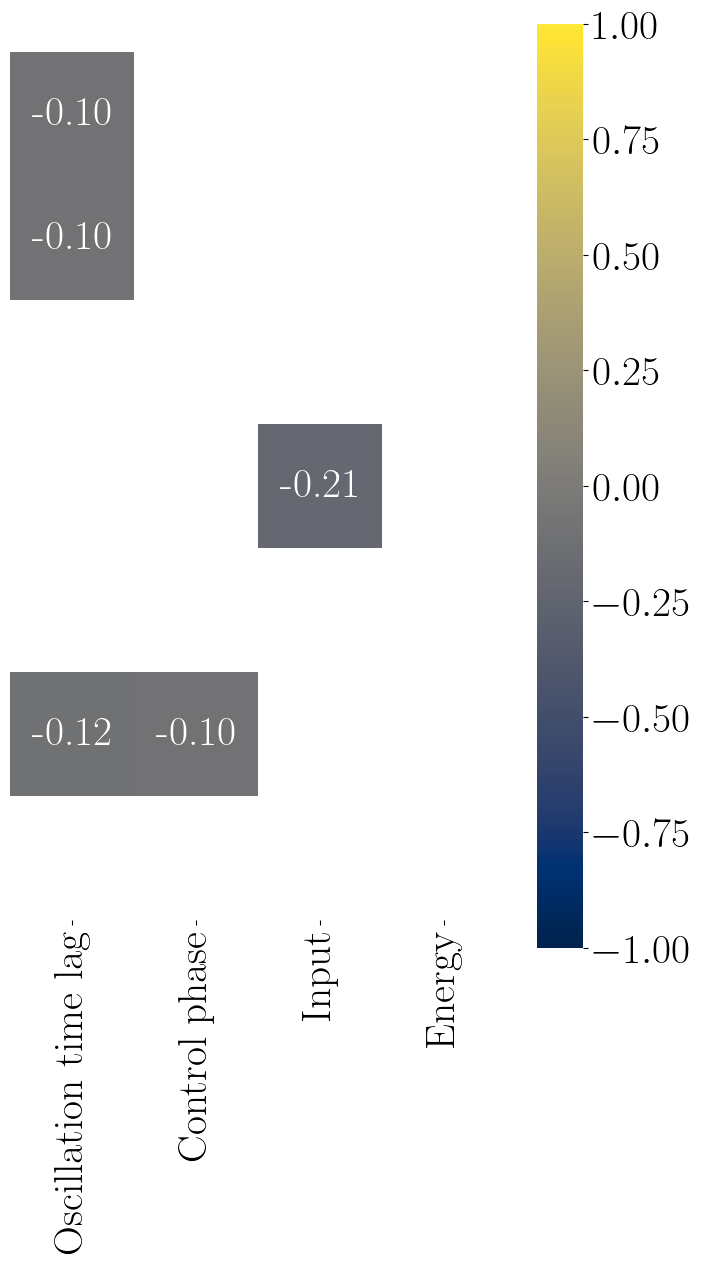

In [46]:
annotations = r_mat_sc_cd_sync.copy()

print(p_mat_sc_cd_sync[1,:])
print(tot_count_mat_sync[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd_sync[ix, iy]/float(tot_count_mat_sync[ix,iy]) <=0.5:
            annotations[ix, iy, 0] = None
        else:
            annotations[ix,iy, 0] = np.mean(r_mat_sc_cd_sync[ix, iy, :])/p_mat_sc_cd_sync[ix, iy]

plt.figure(figsize=(8,12))
ax = sns.heatmap(annotations[:,:,0], annot=True, fmt='.2f', cmap=cmap, yticklabels=False, xticklabels=ylabel, vmin=-1, vmax=1, cbar=False)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90) 
plt.savefig(os.path.join(datadir, "sc_cd_sync_var.jpg"), bbox_inches='tight', dpi=300)
plt.show()

annotations = r_mat_sc_cd_sync_cc.copy()

print(p_mat_sc_cd_sync_cc[1,:])
print(tot_count_mat_sync_cc[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd_sync_cc[ix, iy]/float(tot_count_mat_sync_cc[ix,iy]) <=0.5:
            annotations[ix, iy, 0] = None
        else:
            annotations[ix,iy, 0] = np.mean(r_mat_sc_cd_sync_cc[ix, iy, :])/p_mat_sc_cd_sync_cc[ix, iy]

plt.figure(figsize=(8,12))
ax = sns.heatmap(annotations[:,:,0], annot=True, fmt='.2f', cmap=cmap, yticklabels=False, xticklabels=ylabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90) 
plt.savefig(os.path.join(datadir, "sc_cd_sync_cc.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [51]:
#### strongest energy input L2

nodes_0 = [[],[],[]]
nodes_2 = [[],[],[]]

for task in [0,2]:
    for point in [2,0,1]:
        impnodes = []
        for weight in range(3):
            ensort = np.argsort(energy[task, point, weight,:])[-10:]
            for e in ensort:
                impnodes.append(e)

        if task == 0:
            for i in impnodes:
                if impnodes.count(i) > 2:
                    if i not in nodes_0[point]:
                        nodes_0[point].append(i)
                
        elif task == 2:
            for i in impnodes:
                if impnodes.count(i) > 2:
                    if i not in nodes_2[point]:
                        nodes_2[point].append(i)

nodes_1 = [[],[],[]]
node1 = np.zeros((3))
nodes_3 = [[],[],[]]
node3 = np.zeros((3))

for task in [1]:
    for point in [2,0,1]:
        impnodes = []
        for weight in [0,1]:
            print("task, point, weight = ", task, point, weight)
            nodes_1[point] = [i for i,v in enumerate(energy[task, point, weight,:]) if v > 1e-2]
            print("largest nodes = ", nodes_1[point])
        node1[point] = np.argmax(energy[task, point, 0,:])

for task in [3]:
    for point in [2,0,1]:
        impnodes = []
        for weight in [0,1]:
            print("task, point, weight = ", task, point, weight)
            nodes_3[point] = [i for i,v in enumerate(energy[task, point, weight,:]) if v > 1e-2]
            print("largest nodes = ", nodes_3[point])
        node3[point] = np.argmax(energy[task, point, 0,:])

task, point, weight =  1 2 0
largest nodes =  [68]
task, point, weight =  1 2 1
largest nodes =  [30, 58, 67, 68]
task, point, weight =  1 0 0
largest nodes =  [36]
task, point, weight =  1 0 1
largest nodes =  [22, 36, 49, 68]
task, point, weight =  1 1 0
largest nodes =  [71]
task, point, weight =  1 1 1
largest nodes =  [60, 71, 74, 82, 90]
task, point, weight =  3 2 0
largest nodes =  [68]
task, point, weight =  3 2 1
largest nodes =  [30, 31, 58, 67, 68, 78]
task, point, weight =  3 0 0
largest nodes =  [36]
task, point, weight =  3 0 1
largest nodes =  [36, 57, 68, 86]
task, point, weight =  3 1 0
largest nodes =  [9]
task, point, weight =  3 1 1
largest nodes =  [9, 58, 71, 82, 90]


In [52]:
print(" ".join(str(x) for x in np.sort(nodes_0[2])))
print(" ".join(str(x) for x in np.sort(nodes_0[0])))
print(" ".join(str(x) for x in np.sort(nodes_0[1])))
print("---------------")
print(" ".join(str(x) for x in np.sort(nodes_1[2])))
print(" ".join(str(x) for x in np.sort(nodes_1[0])))
print(" ".join(str(x) for x in np.sort(nodes_1[1])))
print("---------------")
print(" ".join(str(x) for x in np.sort(nodes_2[2])))
print(" ".join(str(x) for x in np.sort(nodes_2[0])))
print(" ".join(str(x) for x in np.sort(nodes_2[1])))
print("---------------")
print(" ".join(str(x) for x in np.sort(nodes_3[2])))
print(" ".join(str(x) for x in np.sort(nodes_3[0])))
print(" ".join(str(x) for x in np.sort(nodes_3[1])))
print("---------------")

0 44 50 79 82
0 30 37 44 50 78 82
58 67 71 73 96
---------------
30 58 67 68
22 36 49 68
60 71 74 82 90
---------------
0 50 79
0 44 50 82
61 80 83 85 89
---------------
30 31 58 67 68 78
36 57 68 86
9 58 71 82 90
---------------


In [99]:
import scipy.special

def prob_random_draw(N, n1, n2, k):
    return scipy.special.binom(n1, k) * scipy.special.binom(N-n1, n2-k) / scipy.special.binom(N, n2)

print(prob_random_draw(100, 5, 6, 3)*100)

0.11611486206478842


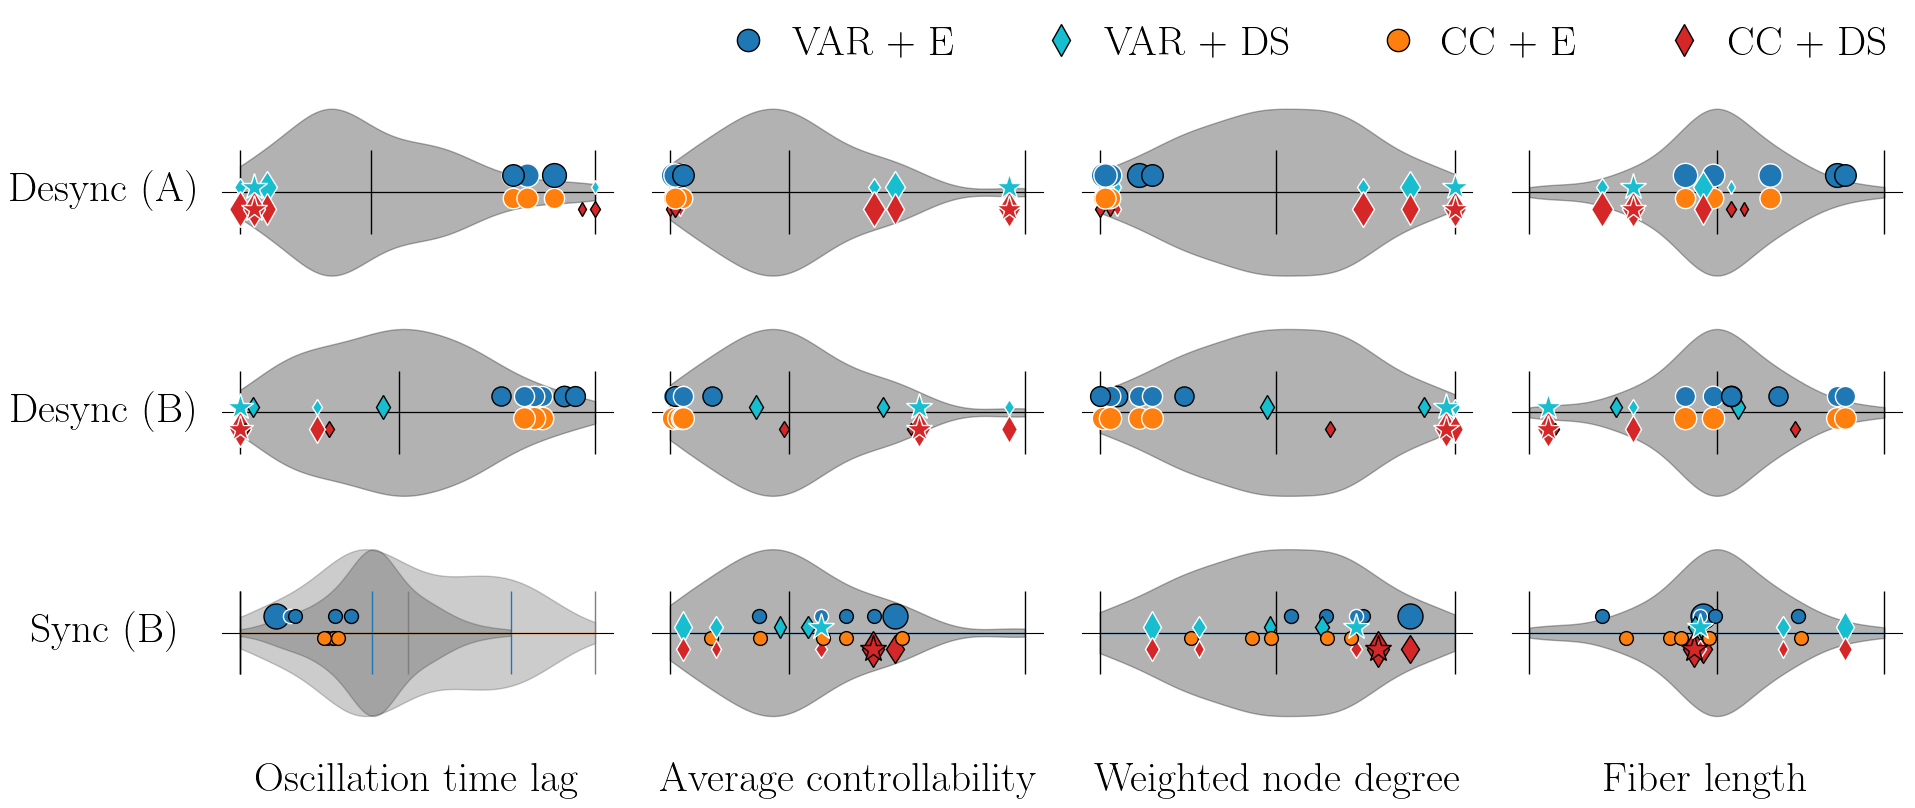

In [ ]:
ylabel = ["Desync (A)", "Desync (B)", "Sync (B)"]
xlabel = ["Oscillation time lag", "Average controllability", "Weighted node degree", "Fiber length"]
colmap = mpl.colormaps["tab10"]

overlap_a = [30, 58, 67, 68, 0, 50, 79]
overlap_b = [36, 68, 0, 44, 50, 82]
overlap_sb = [71, 82, 90]

overlap = [ overlap_b, overlap_sb, overlap_a]

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

msbase = 6
msscale = 12


fig, ax = plt.subplots(3, 4, figsize=(24,8))

for ir, task in enumerate([2,0,1]):

    for n in range(N):
        if n in nodes_0[task]:
            col = colmap(0)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = 0.04
            ms = msbase + msscale * np.sqrt(np.mean(energy[0,task,:,n])/np.mean(  [np.amax(energy[0,task,0,:]), np.amax(energy[0,task,1,:]), np.amax(energy[0,task,2,:]) ]))
            ax[ir,0].plot(peak_times[0,task,0,n], shift, marker="o", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,3].plot(nfl[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        if n == node1[task]:
            col = colmap(0.9)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = 0.0133
            ms = 20
            if ir != 2:
                ax[ir,0].plot(peak_times[1,task,0,n], shift, marker="*", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=20)
            ax[ir,1].plot(av_c[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
            ax[ir,2].plot(wnd[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
            ax[ir,3].plot(nfl[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
        if n in nodes_1[task] and n != node1[task]:
            col = colmap(0.9)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = 0.0133
            ms =  msbase + msscale * np.sqrt(energy[1,task,1,n]/np.amax(energy[1,task,1,:]))
            if ir != 2:
                ax[ir,0].plot(peak_times[1,task,0,n], shift, marker="d", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,3].plot(nfl[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        if n in nodes_2[task]:
            col = colmap(0.1)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = -0.0133
            ms =  msbase + msscale * np.sqrt(np.mean(energy[2,task,:,n])/np.mean(  [np.amax(energy[2,task,0,:]), np.amax(energy[2,task,1,:]), np.amax(energy[2,task,2,:]) ]))
            ax[ir,0].plot(peak_times[2,task,0,n], shift, marker="o", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,3].plot(nfl[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        if n == node3[task]:
            col = colmap(0.3)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = -0.04
            ms = 20
            if ir != 2:
                ax[ir,0].plot(peak_times[3,task,0,n], shift, marker="*", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=20)
            ax[ir,1].plot(av_c[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
            ax[ir,2].plot(wnd[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
            ax[ir,3].plot(nfl[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
        if n in nodes_3[task] and n != node3[ir]:
            col = colmap(0.3)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = -0.04
            ms =  msbase + msscale * np.sqrt(energy[3,task,1,n]/np.amax(energy[3,task,1,:]))
            if ir != 2:
                ax[ir,0].plot(peak_times[3,task,0,n], shift, marker="d", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,3].plot(nfl[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        #else:
        #    ax[ir,0].plot(peak_times[0,ir,2,n], 0, marker="x", linestyle="none", color="k")
        #    ax[ir,1].plot(av_c[n], 0, marker="x", linestyle="none", color="k")
        #    ax[ir,2].plot(wnd[n], 0, marker="x", linestyle="none", color="k")
        #    ax[ir,3].plot(nfl[n], 0, marker="x", linestyle="none", color="k")

    if ir == 2:
        p00 = ax[ir,0].violinplot(peak_times[0,task,0,:], positions=0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
        #p01 = ax[ir,0].violinplot(peak_times[1,task,0,:], positions=0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
        p02 = ax[ir,0].violinplot(peak_times[2,task,0,:], positions=-0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
        #p03 = ax[ir,0].violinplot(peak_times[3,task,0,:], positions=0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
    else:
        p0 = ax[ir,0].violinplot(peak_times[0,task,0,:], positions=np.zeros((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
    p1 = ax[ir,1].violinplot(av_c, positions=np.zeros((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
    p2 = ax[ir,2].violinplot(wnd, positions=np.zeros((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
    p3 = ax[ir,3].violinplot(nfl, positions=np.zeros((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)

    if ir == 2:
        for p in [p00, p02]: #p01, p02, p03]:
            for bod in p['bodies']:
                bod.set_facecolor('k')
                bod.set_edgecolor('k')
                bod.set_alpha(0.2)
            p['cmins'].set_color('k')

        p00['cmeans'].set_color(colmap(0))
        p00['cmaxes'].set_color(colmap(0))
        #p01['cmeans'].set_color(colmap(0.333))
        #p01['cmaxes'].set_color(colmap(0.333))
        p02['cmeans'].set_color(colmap(0.73))
        p02['cmaxes'].set_color(colmap(0.73))
        #p03['cmeans'].set_color(colmap(0.95))
        #p03['cmaxes'].set_color(colmap(0.95))
    else:
        for bod in p0['bodies']:
            bod.set_facecolor('k')
            bod.set_edgecolor('k')
            bod.set_alpha(0.3)
        p0['cmeans'].set_color('k')
        p0['cmaxes'].set_color('k')
        p0['cmins'].set_color('k')
    for p in [p1, p2, p3]:
        for bod in p['bodies']:
            bod.set_facecolor('k')
            bod.set_edgecolor('k')
            bod.set_alpha(0.3)
        p['cmeans'].set_color('k')
        p['cmaxes'].set_color('k')
        p['cmins'].set_color('k')

    x_ = [np.amin(peak_times[1,task,0,n]), np.amax(peak_times[1,task,0,:])]
    #ax[ir,0].set_xlim(x_)
    ax[ir,0].set_xticks([])
    
    x_ = [np.amin(av_c), np.amax(av_c)]
    #ax[ir,1].set_xlim(x_)
    ax[ir,1].set_xticks([])

    x_ = [np.amin(wnd), np.amax(wnd)]
    #ax[ir,2].set_xlim(x_)
    ax[ir,2].set_xticks([])

    x_ = [np.amin(nfl), np.amax(nfl)]
    #ax[ir,3].set_xlim(x_)
    ax[ir,3].set_xticks([])

    for k in range(4):
        ax[ir,k].set_yticks([])
        #ax[ir,k].set_ylim(-0.1,0.1)

        ax[ir,k].spines['right'].set_visible(False)
        ax[ir,k].spines['left'].set_visible(False)
        ax[ir,k].spines['top'].set_visible(False)
        ax[ir,k].spines['bottom'].set_position('zero')

    ax[ir,0].set_ylabel(ylabel[ir], rotation=0)
    ax[ir,0].yaxis.set_label_coords(-0.3, 0.4)

for ic in range(4):
    ax[2,ic].set_xlabel(xlabel[ic])
    ax[2,ic].xaxis.set_label_coords(0.5, -0.2)

fig.align_ylabels([ax[:,0]])

legend_elements = [Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0), marker="o", markeredgecolor="k", markersize=16, label='VAR + E'),
                   Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0.9), marker="d", markeredgecolor="k", markersize=16, label='VAR + DS'),
                   Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0.1), marker="o", markeredgecolor="k", markersize=16, label='CC + E'),
                   Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0.3), marker="d", markeredgecolor="k", markersize=16, label='CC + DS')
                   ]

fig.legend(handles=legend_elements, bbox_to_anchor=(0.1, 0.92, 0.81, .1), labelspacing=0.1, handlelength=0.1, handletextpad=1, frameon=False, ncol=4, columnspacing=2.5)

#fig.legend(handles=legend_elements, loc='upper right')

fig.subplots_adjust(left=0.2, bottom=0.1, right=None, top=None, wspace=0.1, hspace=None)
plt.savefig(os.path.join(datadir, "role_nodes_conn.jpg"), bbox_inches='tight', dpi=300, transparent=True)
plt.show()

0 2
1 0
2 1


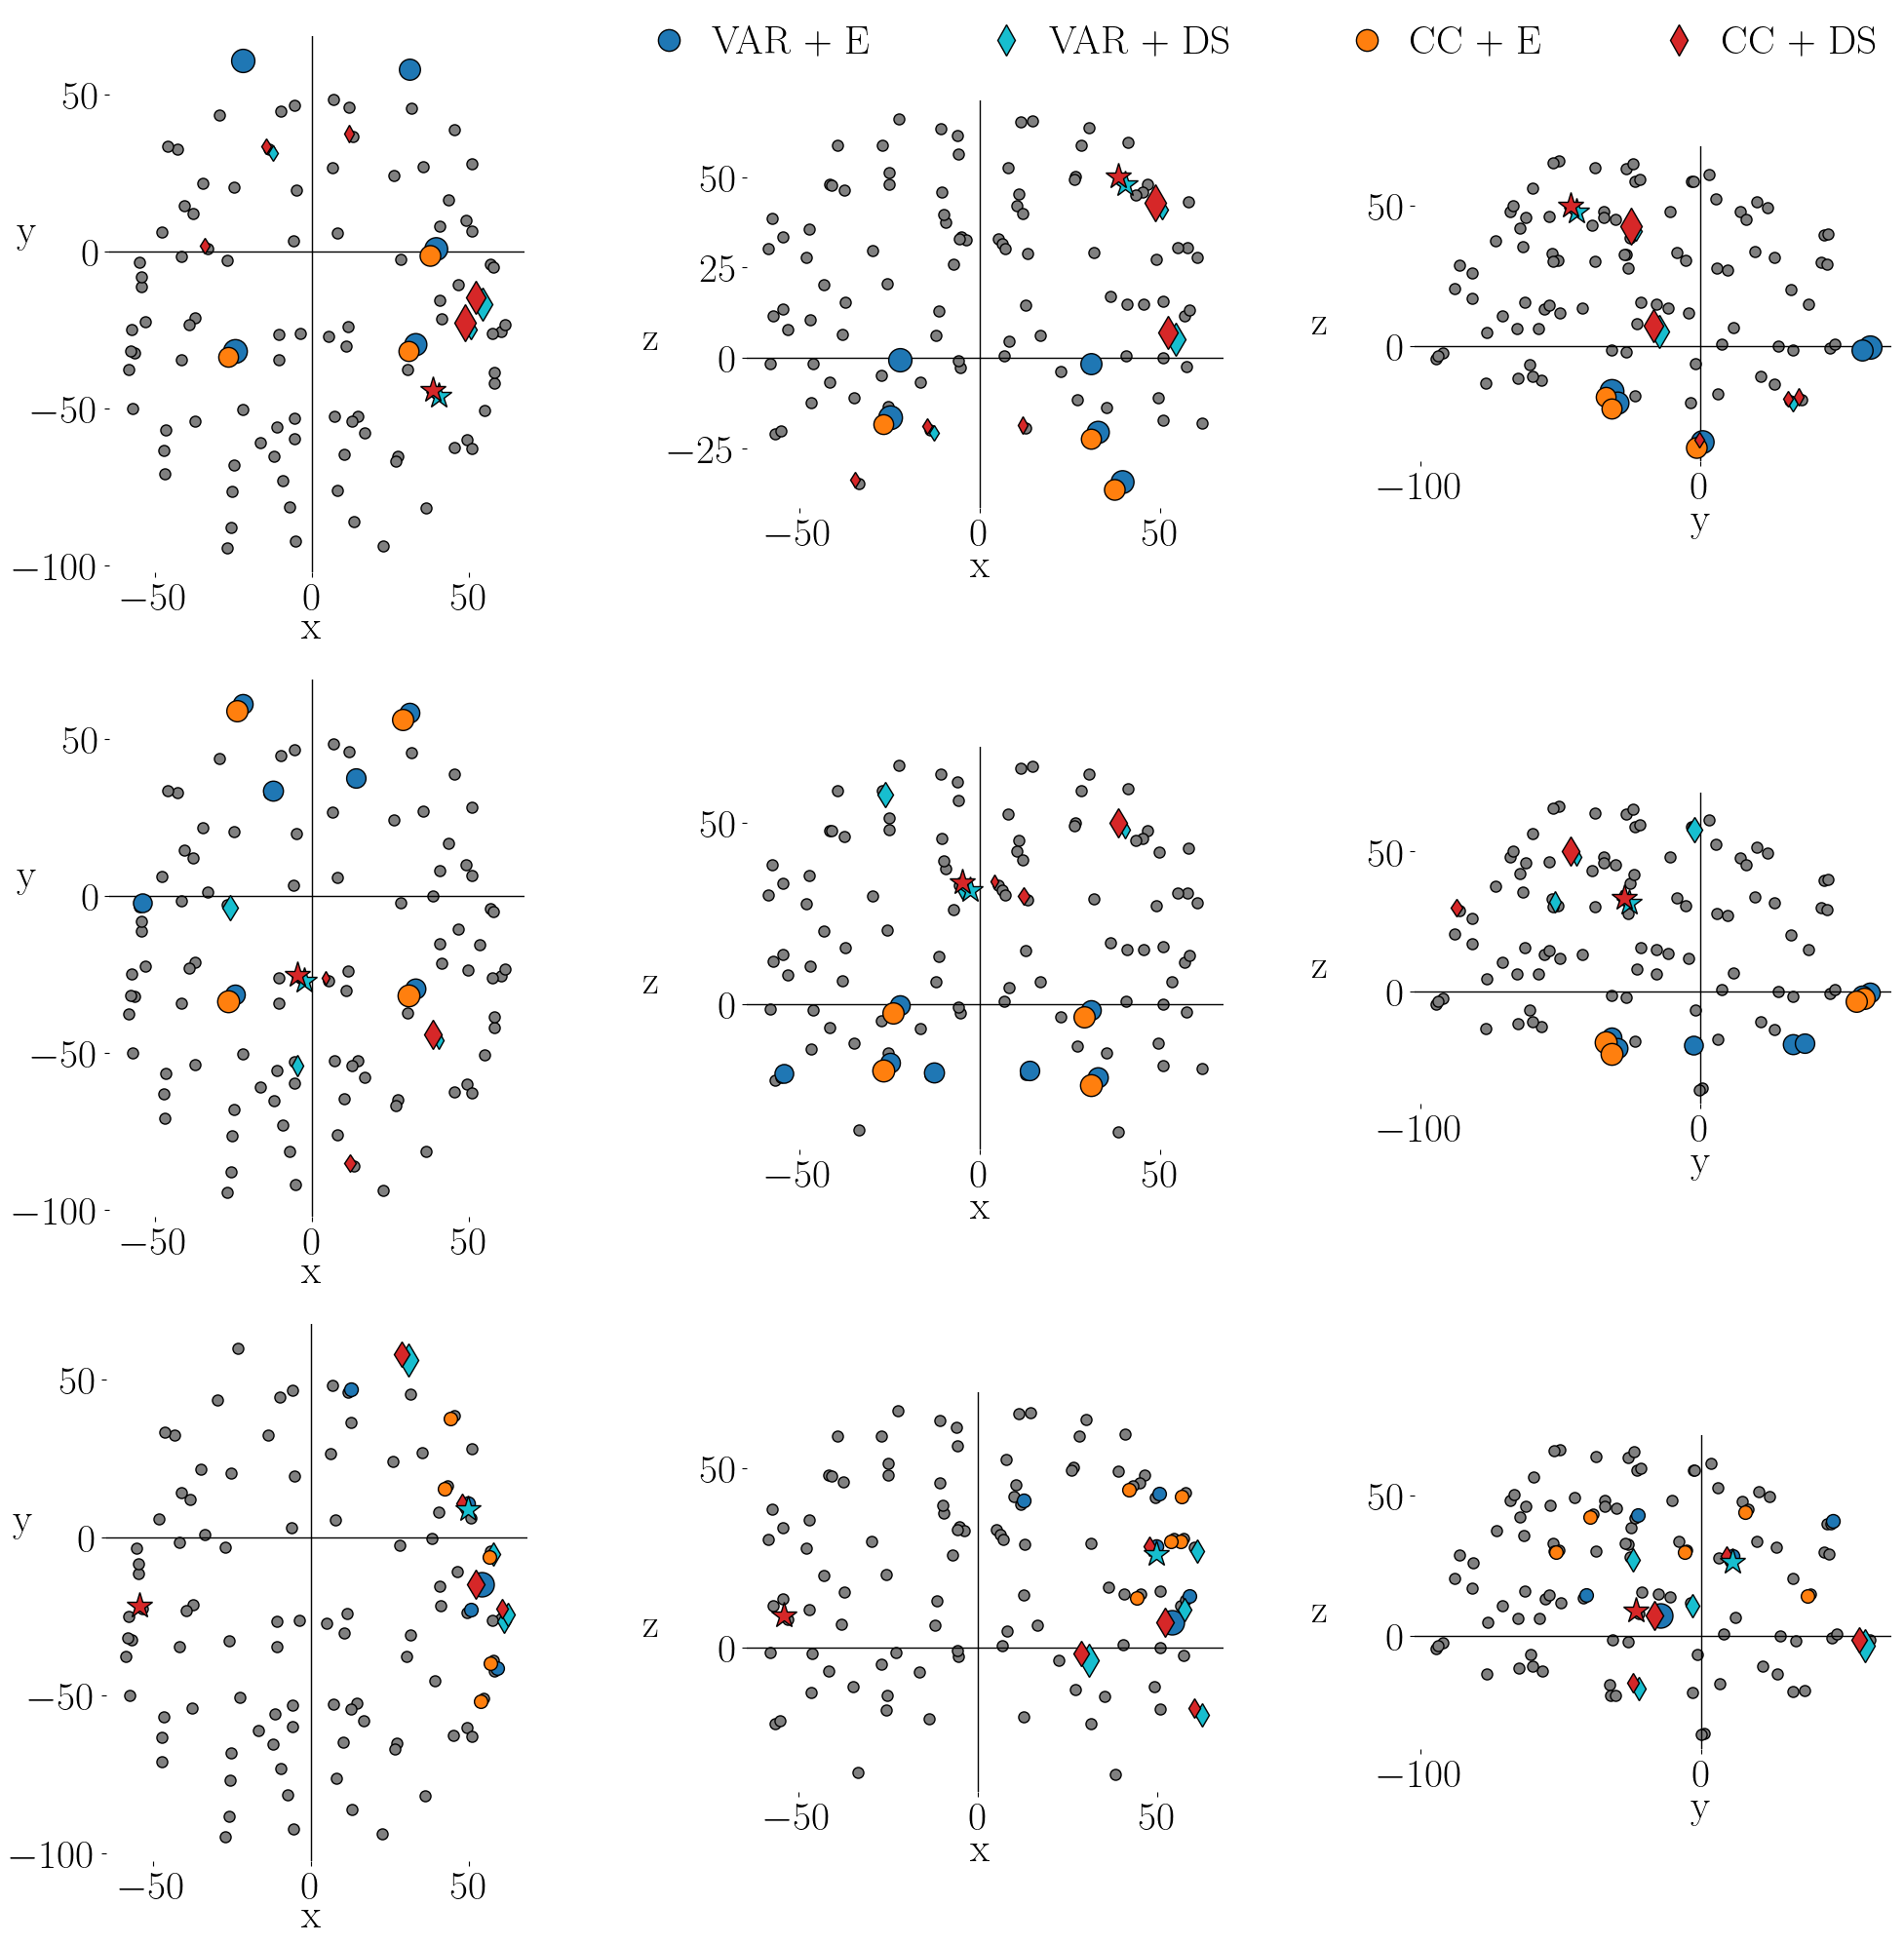

In [445]:
task = 0
point = 0
weight = 0

fig, ax = plt.subplots(3, 3, figsize=(24,24))

maxen = np.amax(energy[task,point,weight,:])
ms = 14
shift = 1.

for ip, task in enumerate([2,0,1]):
    print(ip, task)

    for n in range(N):
        if n in nodes_0[task]:
            col = colmap(0)
            marker_="o"
            markeredgecolor_="k"
            markersize_= msbase + msscale * np.sqrt(np.mean(energy[0,task,:,n])/np.mean(  [np.amax(energy[0,task,0,:]), np.amax(energy[0,task,1,:]), np.amax(energy[0,task,2,:]) ]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]+shift, coord_data[n,1]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]+shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]+shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)

    for n in range(N):
        if n == node1[task]:
            col = colmap(0.9)
            marker_="*"
            markeredgecolor_="k"
            markersize_= 20
            zorder_=20
            ax[ip,0].plot(coord_data[n,0]+shift, coord_data[n,1]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


        elif n in nodes_1[task]:
            col = colmap(0.9)
            marker_="d"
            markeredgecolor_="k"
            markersize_= 1 + msbase + msscale * np.sqrt(energy[1,task,1,n]/np.amax(energy[1,task,1,:]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]+shift, coord_data[n,1]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)

    for n in range(N):
        if n in nodes_2[task]:
            col = colmap(0.1)
            marker_="o"
            markeredgecolor_="k"
            markersize_= msbase + msscale * np.sqrt(np.mean(energy[2,task,:,n])/np.mean(  [np.amax(energy[2,task,0,:]), np.amax(energy[2,task,1,:]), np.amax(energy[2,task,2,:]) ]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]-shift, coord_data[n,1]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]-shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]-shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)

    for n in range(N):
        if n == node3[task]:
            col = colmap(0.3)
            marker_="*"
            markeredgecolor_="k"
            markersize_= 20
            zorder_=20
            ax[ip,0].plot(coord_data[n,0]-shift, coord_data[n,1]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


        elif n in nodes_3[task]:
            col = colmap(0.3)
            marker_="d"
            markeredgecolor_="k"
            markersize_= 1 + msbase + msscale * np.sqrt(energy[3,task,1,n]/np.amax(energy[3,task,1,:]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]-shift, coord_data[n,1]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


for ip, point in enumerate([2,0,1]):
    for n in range(N):

        col = 'gray'
        marker_="o"
        zorder_=-10
        markersize_ = 8
        
        ax[ip,0].plot(coord_data[n,0], coord_data[n,1], marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
        ax[ip,1].plot(coord_data[n,0], coord_data[n,2], marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
        ax[ip,2].plot(coord_data[n,1], coord_data[n,2], marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


    for k in range(3):
        ax[ip, k].set_aspect('equal', adjustable='box')
        ax[ip, k].axhline(y=0, color='k')
        ax[ip, k].axvline(x=0, color='k')

        #ax[k].get_xaxis().set_visible(False)

        ax[ip, k].spines['right'].set_visible(False)
        ax[ip, k].spines['left'].set_visible(False)
        ax[ip, k].spines['top'].set_visible(False)
        ax[ip, k].spines['bottom'].set_visible(False)

    ax[ip, 0].set_xlabel("x")
    ax[ip, 0].set_ylabel("y", rotation=0)

    ax[ip, 1].set_xlabel("x")
    ax[ip, 1].set_ylabel("z", rotation=0)

    ax[ip, 2].set_xlabel("y")
    ax[ip, 2].set_ylabel("z", rotation=0)

    ax[ip, 0].xaxis.set_label_coords(0.485, -0.07)
    ax[ip, 0].yaxis.set_label_coords(-0.2, 0.6)

    ax[ip, 1].xaxis.set_label_coords(0.49, -0.1)
    ax[ip, 1].yaxis.set_label_coords(-0.2, 0.37)

    ax[ip, 2].xaxis.set_label_coords(0.6, -0.13)
    ax[ip, 2].yaxis.set_label_coords(-0.2, 0.38)

fig.legend(handles=legend_elements, bbox_to_anchor=(0.1, 0.8, 0.81, .1), labelspacing=0.1, handlelength=0.1, handletextpad=1, frameon=False, ncol=4, columnspacing=3.3)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.4, hspace=0.2)
plt.box(False)
plt.savefig(os.path.join(datadir, "brain_map.jpg"), bbox_inches='tight', dpi=300, transparent=True)

plt.show()

In [302]:
def norm_time(state, time):
    state_norm = np.zeros((len(time)))
   
    ratio = len(state[:])/len(time)

    if ratio == 1:
        state_norm = state.copy()
    elif ratio > 1:
        skip_ind = 1./(ratio-1.)
        t_count = 0
        mult_r = 0
        for t in range(len(time)):
            state_norm[t] = state[t_count]
            t_count += 1
            if t > mult_r*skip_ind:
                mult_r += 1
                t_count += 1
    else:
        repeat_ind = 1./(1.-ratio)
        t_count = 0
        mult_r = 0
        for t in range(len(time)):
            state_norm[t] = state[t_count]
            t_count += 1
            if t > mult_r*repeat_ind:
                mult_r += 1
                t_count -= 1

    return state_norm

In [400]:
#fig, ax = plt.subplots(3,1, figsize=(24,20))

controls_desync_a = None
controls_desync_b = None
controls_sync_b = None
controls_sync_b_cc = None
controls_sync_b_var = None


indpm = 260

for d in [d0_var_L2, d0_cc_L2]:
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                #ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,0,tps[n,0]:tps[n,1]+1], time)
                #ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0]+100
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,0,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,0,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    #ax[2].plot(c_norm[0,:])

                    if type(controls_desync_b) == type(None):
                        controls_desync_b = c_norm.copy()
                    else:
                        controls_desync_b = np.concatenate((controls_desync_b, c_norm), axis=0)

    print(controls_desync_b.shape)


for d in [d2_var_L2, d2_cc_L2]:
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                #ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,0,tps[n,0]:tps[n,1]+1], time)
                #ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0]+100
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,0,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,0,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    #ax[2].plot(c_norm[0,:])

                    if type(controls_desync_a) == type(None):
                        controls_desync_a = c_norm.copy()
                    else:
                        controls_desync_a = np.concatenate((controls_desync_a, c_norm), axis=0)

    print(controls_desync_a.shape)


#ax[0].set_title("Point (B) desync: CC + E")
#ax[0].set_ylabel("Activity")

plt.show()


for d in [d1_var_L2]:
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 

                control_norm[n,:] = norm_time(d["control"][wi][n,0,tps[n,0]:tps[n,1]+1], time)

                inittime = tps[n,0]
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,0,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,0,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]

                    if c_norm.shape[1] != (2*indpm)+1: continue

                    if type(controls_sync_b_var) == type(None):
                        controls_sync_b_var = c_norm.copy()
                    else:
                        controls_sync_b_var = np.concatenate((controls_sync_b_var, c_norm), axis=0)

    print(controls_sync_b_var.shape)

for d in [d1_cc_L2]:
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 

                control_norm[n,:] = norm_time(d["control"][wi][n,0,tps[n,0]:tps[n,1]+1], time)

                inittime = tps[n,0]
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,0,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,0,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]

                    if c_norm.shape[1] != (2*indpm)+1: continue

                    print(n, c_norm.shape, inittime, cpeaktime)

                    if type(controls_sync_b_cc) == type(None):
                        controls_sync_b_cc = c_norm.copy()
                    else:
                        controls_sync_b_cc = np.concatenate((controls_sync_b_cc, c_norm), axis=0)

    print(controls_sync_b_cc.shape)

    controls_sync_b = np.concatenate((controls_sync_b_cc, controls_sync_b_var), axis=0)

................. 0
................. 1
................. 2
(630, 521)
................. 0
................. 1
................. 2
(1214, 521)
................. 0
................. 1
................. 2
(779, 521)
................. 0
................. 1
................. 2
(1497, 521)
................. 0
................. 1
................. 2
(649, 521)
................. 0
75 (1, 521) 140 [284]
93 (1, 521) 121 [291]
75 (1, 521) 589 [263]
93 (1, 521) 571 [270]
75 (1, 521) 1039 [240]
91 (1, 521) 1034 [275]
93 (1, 521) 1020 [250]
................. 1
0 (1, 521) 126 [303]
1 (1, 521) 102 [291]
2 (1, 521) 74 [281]
3 (1, 521) 71 [277]
4 (1, 521) 41 [280]
5 (1, 521) 15 [286]
6 (1, 521) 65 [274]
7 (1, 521) 18 [286]
8 (1, 521) 1 [281]
9 (1, 521) 85 [281]
10 (1, 521) 105 [287]
11 (1, 521) 91 [280]
12 (1, 521) 72 [274]
13 (1, 521) 23 [286]
15 (1, 521) 93 [285]
16 (1, 521) 65 [271]
17 (1, 521) 1 [285]
18 (1, 521) 38 [278]
20 (1, 521) 396 [307]
21 (1, 521) 50 [277]
22 (1, 521) 4 [292]
23 (1, 521) 74

/tmp/ipykernel_475329/467933031.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('tab10')


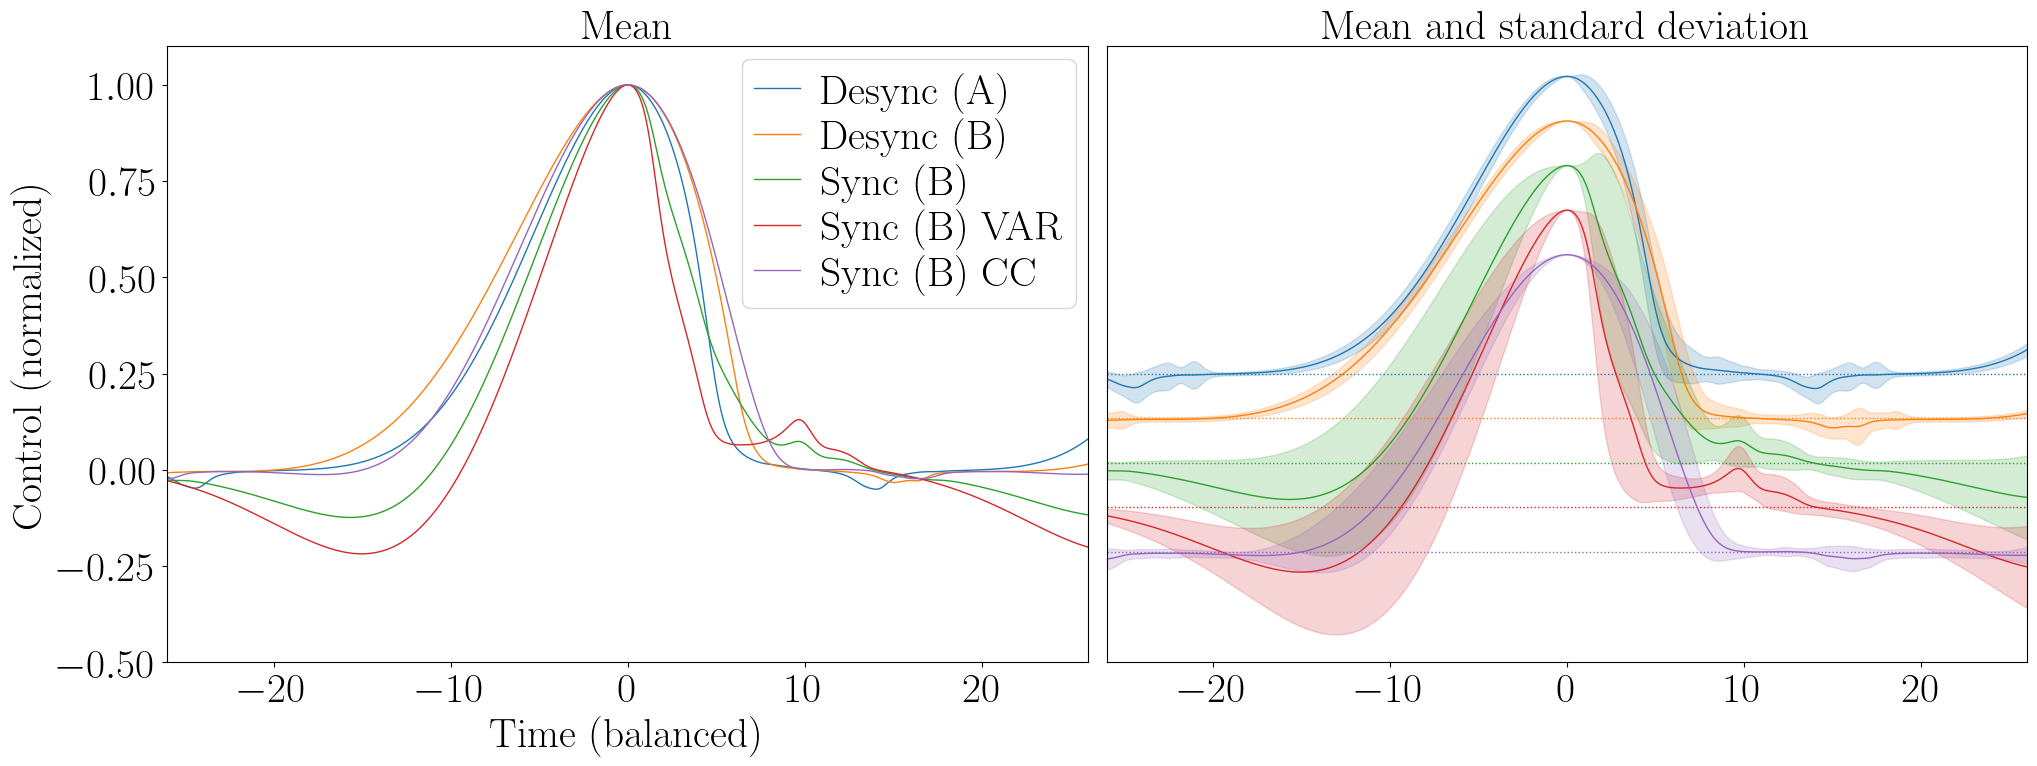

In [ ]:
titles = ["Desync (A)", "Desync (B)", "Sync (B)", "Sync (B) VAR", "Sync (B) CC"]
alpha = 0.2
time = np.arange(-indpm*dt, indpm*dt+dt, dt)


colmap = mpl.cm.get_cmap('tab10')
fig, ax = plt.subplots(1,2, figsize=(24,8), sharex=True)

ofstep = 0.15
colstep = 0.1

###############
cmean = np.mean(controls_desync_a, axis=0)
cstd = np.std(controls_desync_a, axis=0)

colind = 0.0
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[0])

offset = 0.6
ax[1].plot(time, offset+cmean, color=col, label=titles[0])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = np.mean(controls_desync_b, axis=0)
cstd = np.std(controls_desync_b, axis=0)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[1])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[1])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = np.mean(controls_sync_b, axis=0)
cstd = np.std(controls_sync_b, axis=0)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[2])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[4])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)


###############
cmean = np.mean(controls_sync_b_var, axis=0)
cstd = np.std(controls_sync_b_var, axis=0)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[3])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[3])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = np.mean(controls_sync_b_cc, axis=0)
cstd = np.std(controls_sync_b_cc, axis=0)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[4])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[2])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)


###############
ax[0].set_title("Mean")
ax[1].set_title("Mean and standard deviation")

ax[0].legend(loc="upper right", labelspacing=0.1, handlelength=1.1, handletextpad=0.5, borderpad=0.3, borderaxespad=0.3)
#ax[1].legend(loc="upper right")

ax[0].set_ylim(-0.5, 1.1)
#ax[1].set_ylim(-0.5, 1.1)

ax[0].set_ylabel("Control (normalized)")

ax[0].set_xlim([-indpm*dt,indpm*dt])
ax[0].set_xlabel("Time (balanced)")
ax[1].set_yticks([])
ax[0].set_xlim([-indpm*dt, indpm*dt])

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.02, hspace=0.0)
plt.savefig(os.path.join(datadir, "meanOC.jpg"), bbox_inches='tight', dpi=300)
plt.show()

................. 0
36
68
................. 1
36
68
................. 2
36
68
(11, 521)
................. 0
36
68
................. 1
36
68
................. 2
36
68
(17, 521)
................. 0
................. 1
................. 2
(17, 521)
................. 0
................. 1
................. 2
(32, 521)


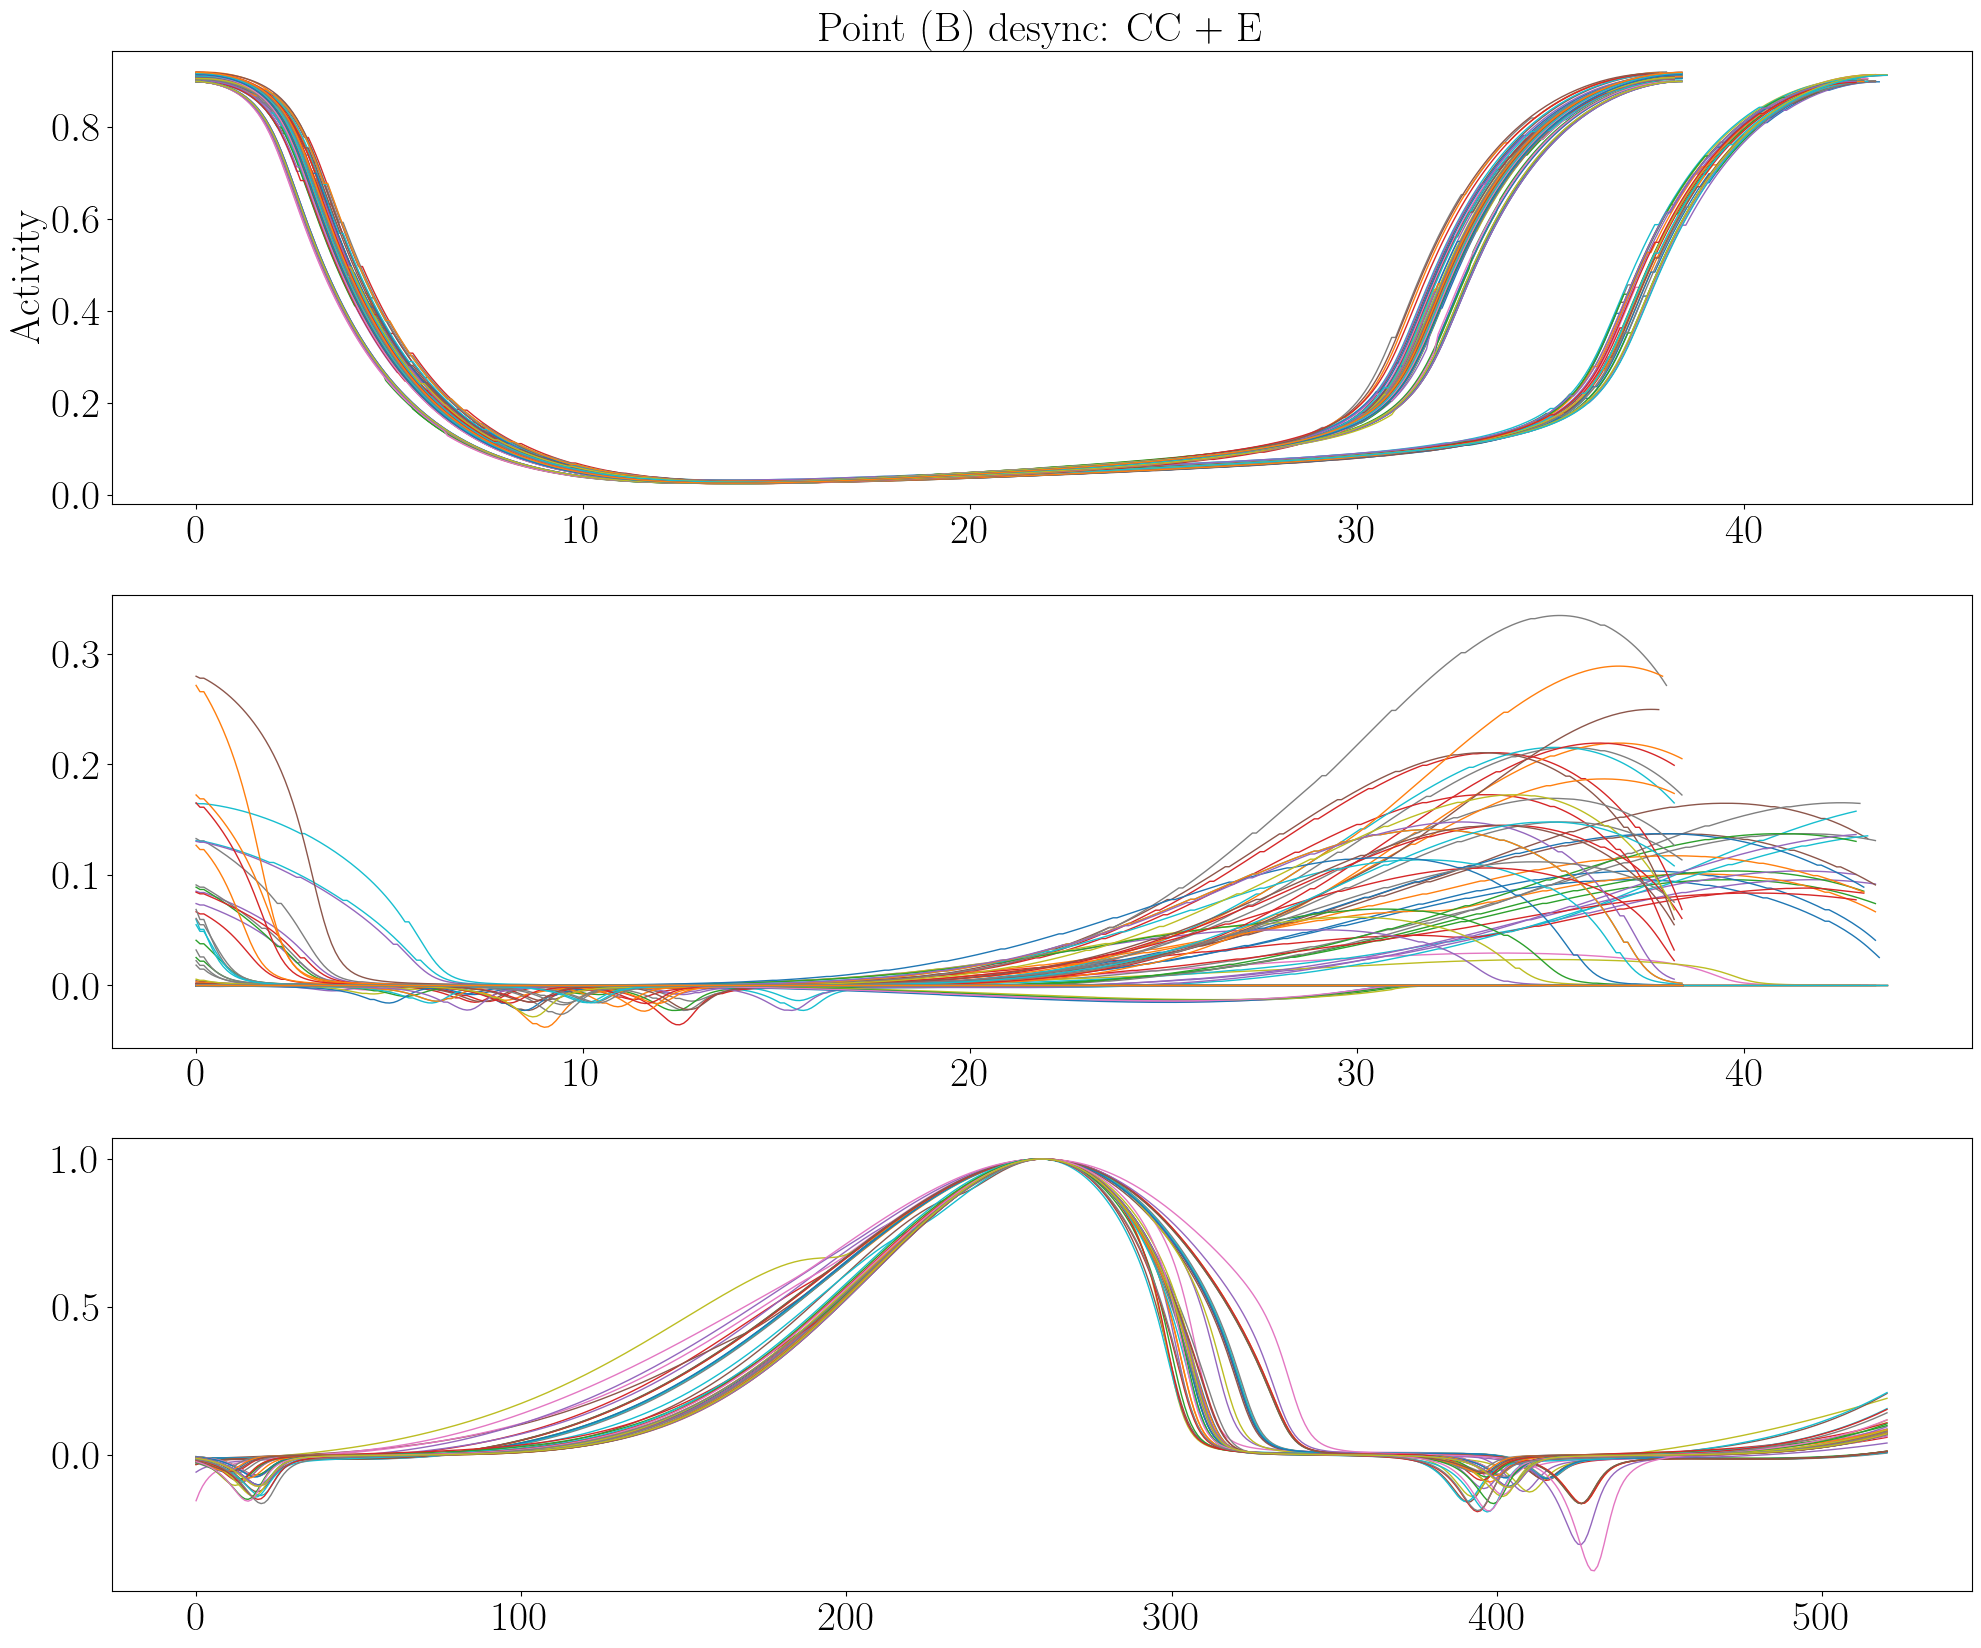

................. 0
[204]
[]
[]
[191]
[]
[]
[183]
[]
[]
................. 1
[203]
[204]
[214]
[190]
[187]
[207]
[181]
[170]
[203]
................. 2
[]
[]
[]
[]
[]
[]
[]
[]
[]
(12, 521)
................. 0
[]
[]
[]
[]
[]
[]
[]
[]
[]
................. 1
[192]
[184]
[197]
[185]
[166]
[190]
[180]
[150]
[186]
................. 2
[]
[]
[]
[]
[]
[]
[]
[]
[]
(21, 521)


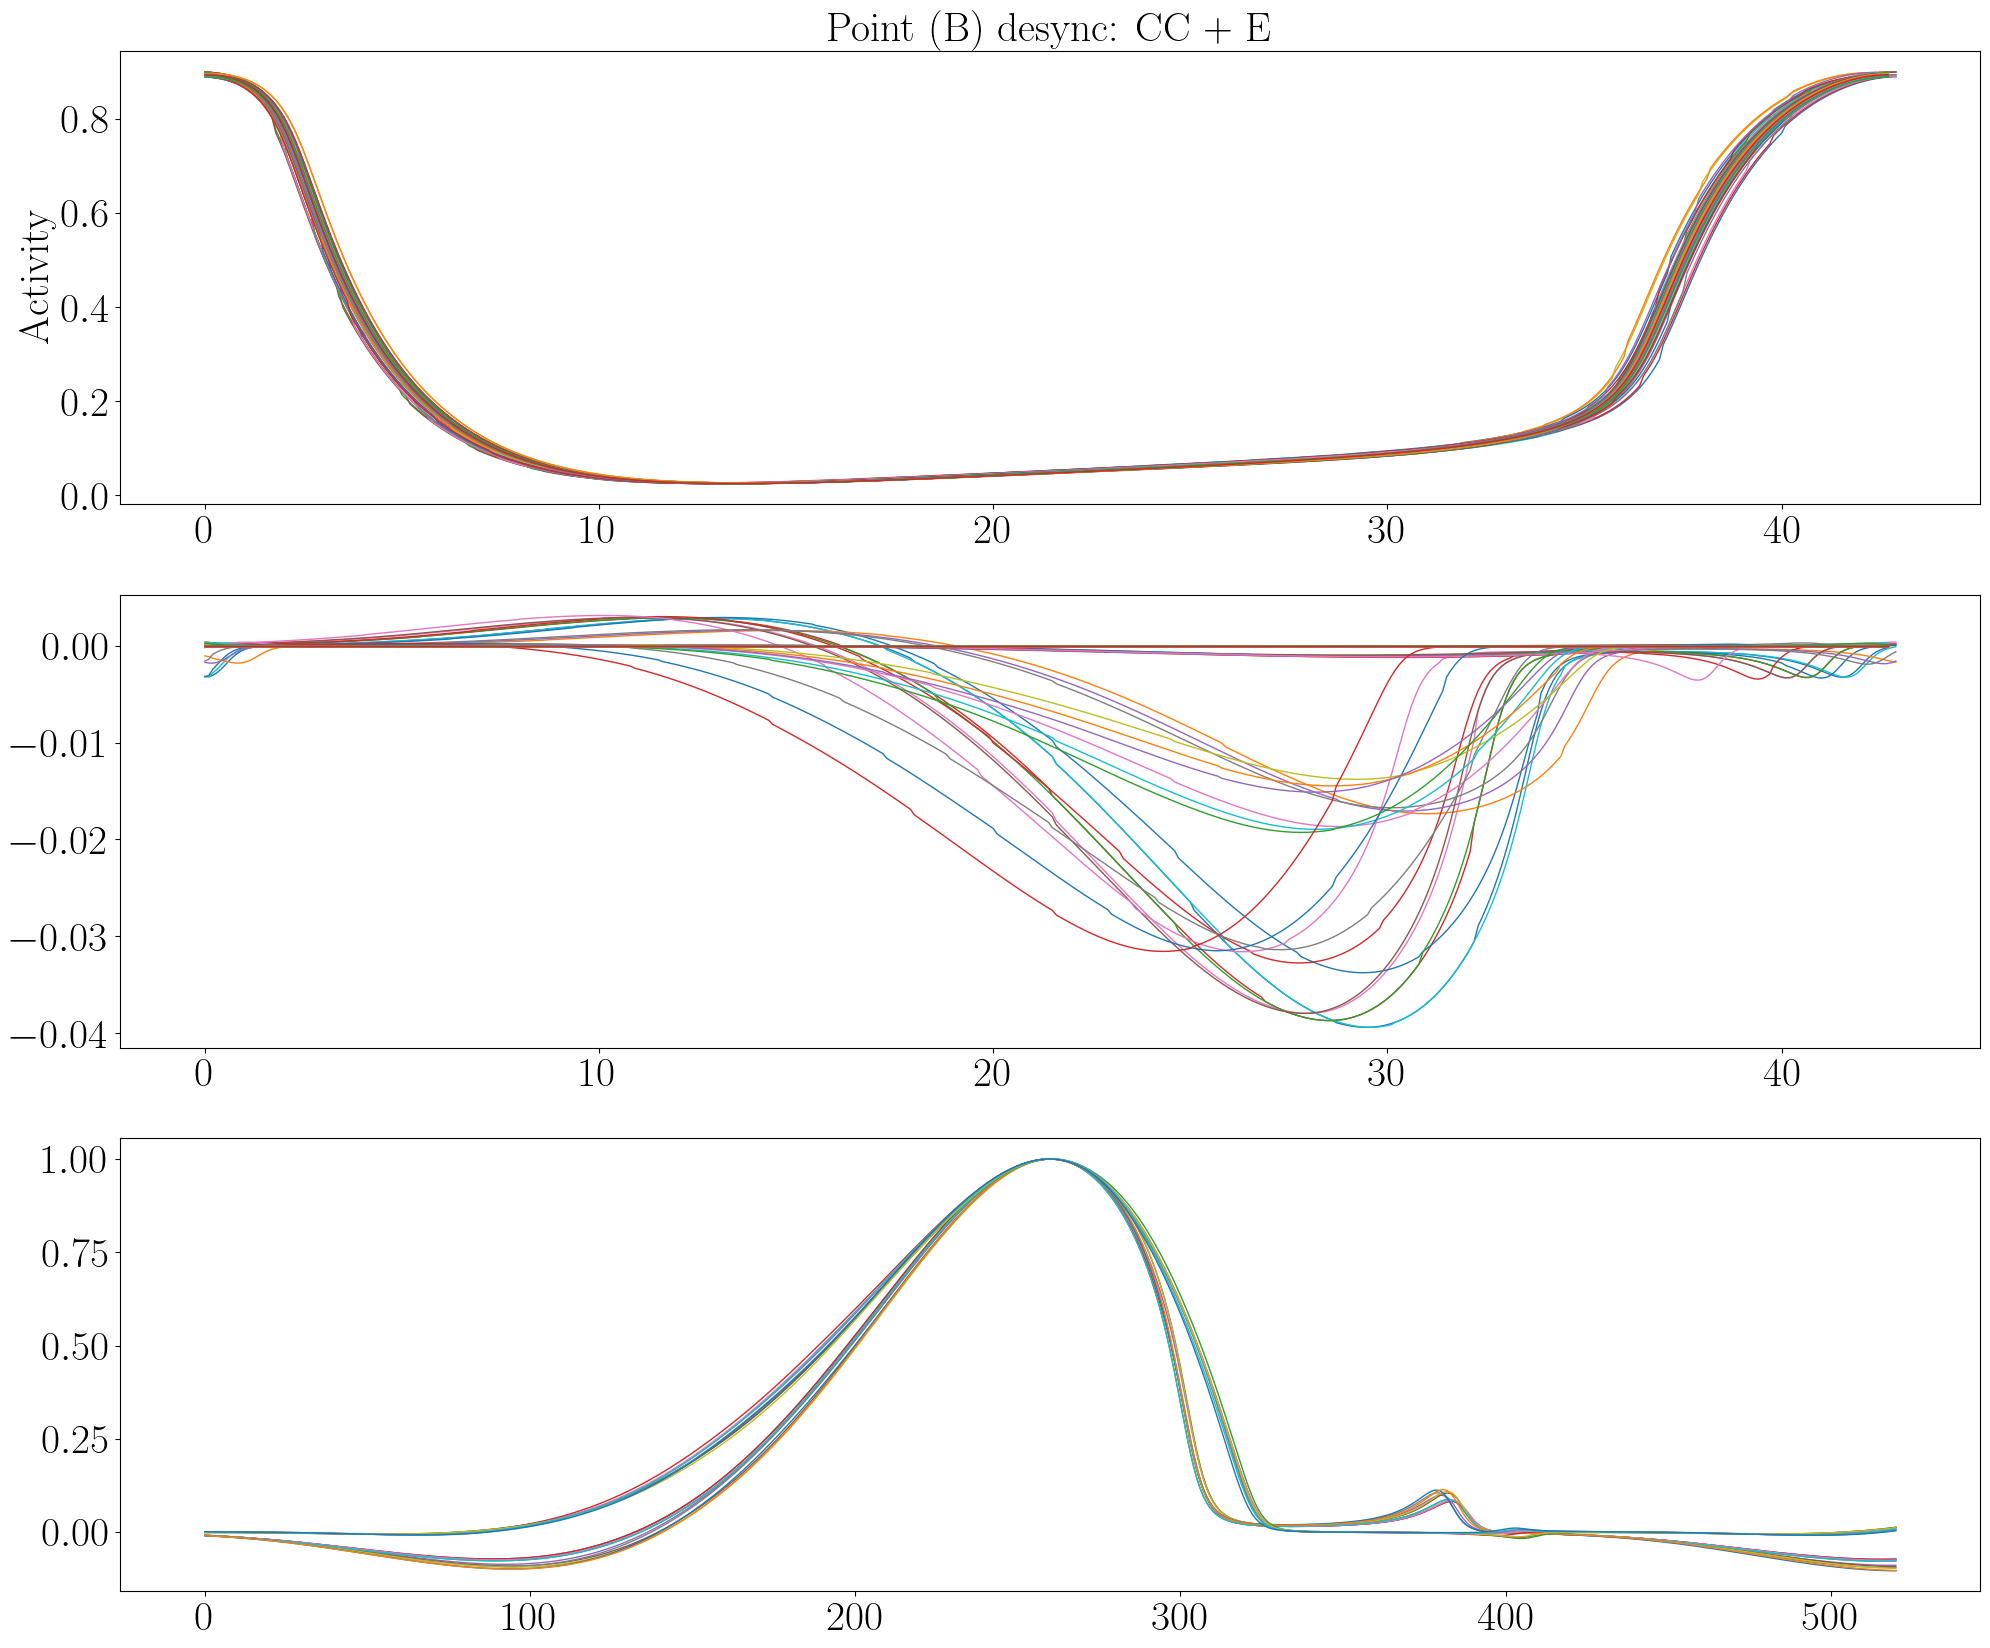

In [396]:
controls_desync_a = None
controls_desync_b = None
controls_sync_b = None
controls_sync_b_cc = None
controls_sync_b_var = None

fig, ax = plt.subplots(3,1, figsize=(24,20))

indpm = 260

for d in [d0_var_L1, d0_cc_L1]:
#for d in [d0_cc_L1]:
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                if n not in nodes_1[0] or n not in nodes_3[0]: continue

                if tpind == 2:
                    print(n)

                if tpind == 2 and n == 68: continue

                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,0,tps[n,0]:tps[n,1]+1], time)
                ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0] + 200
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = [cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,0,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,0,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    ax[2].plot(c_norm[0,:])

                    if type(controls_desync_b) == type(None):
                        controls_desync_b = c_norm.copy()
                    else:
                        controls_desync_b = np.concatenate((controls_desync_b, c_norm), axis=0)

    print(controls_desync_b.shape)


for d in [d2_var_L1, d2_cc_L1]:
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                if n not in nodes_1[2] or n not in nodes_3[2]: continue
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,0,tps[n,0]:tps[n,1]+1], time)
                ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0]+200
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,0,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,0,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    ax[2].plot(c_norm[0,:])

                    if type(controls_desync_a) == type(None):
                        controls_desync_a = c_norm.copy()
                    else:
                        controls_desync_a = np.concatenate((controls_desync_a, c_norm), axis=0)

    print(controls_desync_a.shape)


ax[0].set_title("Point (B) desync: CC + E")
ax[0].set_ylabel("Activity")

plt.show()

fig, ax = plt.subplots(3,1, figsize=(24,20))

for d in [d1_var_L1, d1_cc_L1]:
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                if n not in nodes_1[1] or n not in nodes_3[1]: continue
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,0,tps[n,0]:tps[n,1]+1], time)
                ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0] + 100
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,0,inittime:tps[n,1]+1]), height=0.01)[0]
                print(cpeaktime)
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,0,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,0,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,0,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    ax[2].plot(c_norm[0,:])

                    if c_norm.shape[1] != (2*indpm)+1: continue

                    if type(controls_sync_b) == type(None):
                        controls_sync_b = c_norm.copy()
                    else:
                        controls_sync_b = np.concatenate((controls_sync_b, c_norm), axis=0)

    print(controls_sync_b.shape)

ax[0].set_title("Point (B) desync: CC + E")
ax[0].set_ylabel("Activity")

plt.show()


/tmp/ipykernel_475329/3933081813.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('tab10')


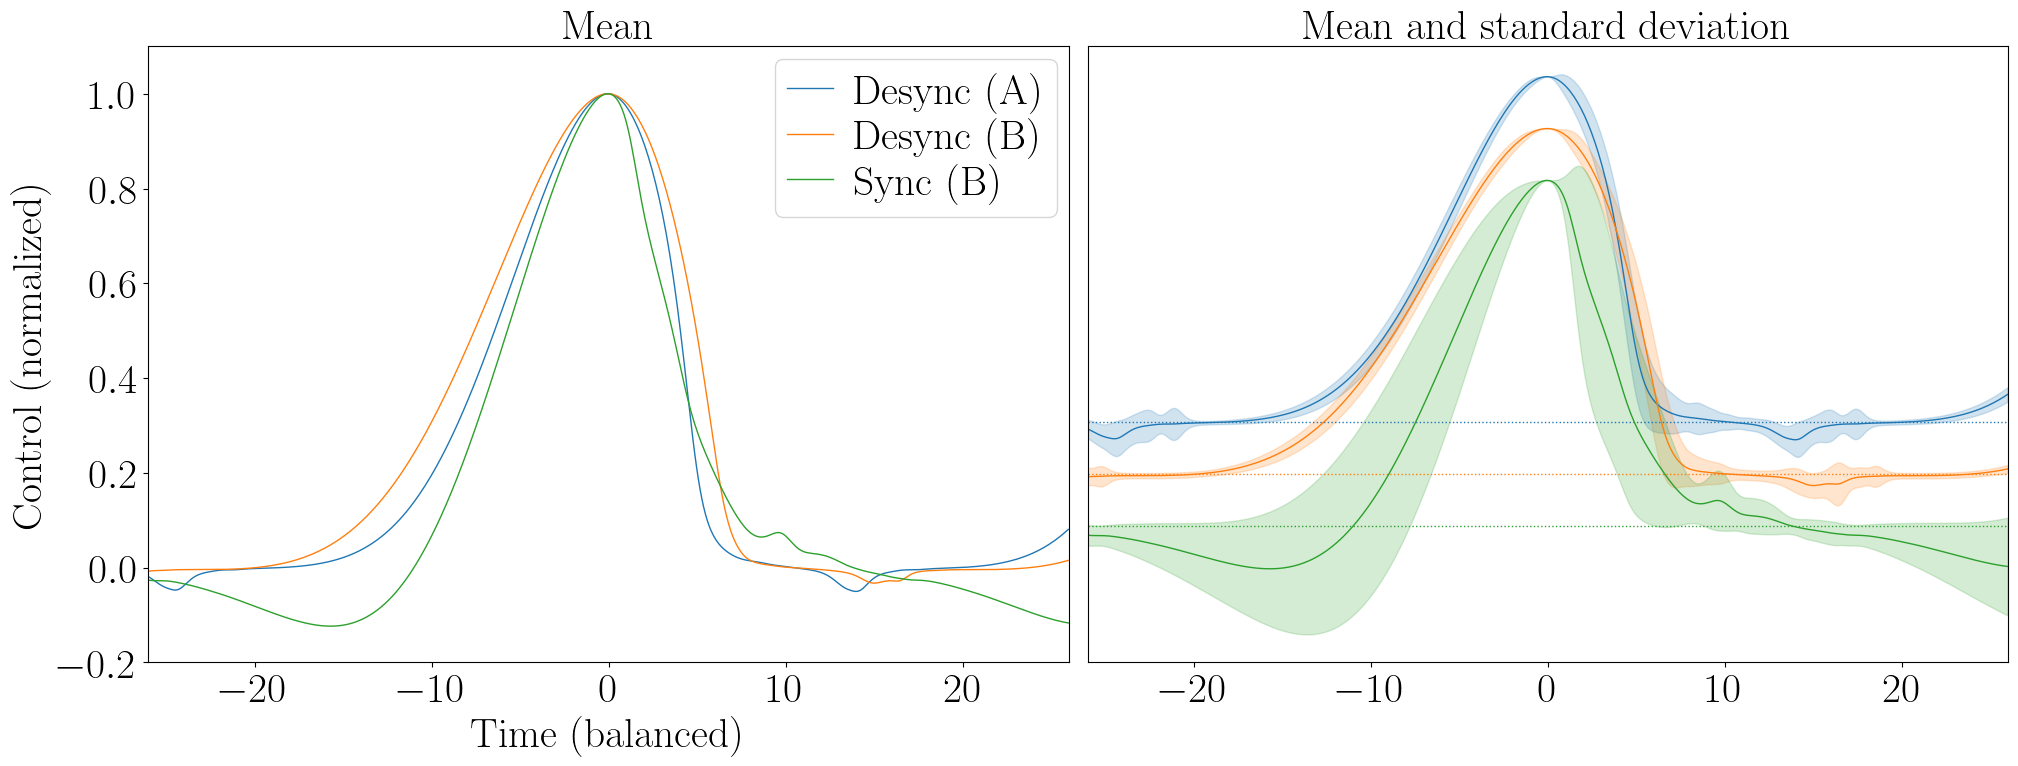

In [416]:
titles = ["Desync (A)", "Desync (B)", "Sync (B)", "Sync (B) VAR", "Sync (B) CC"]
alpha = 0.2
time = np.arange(-0.5*(len(cmean))*dt, 0.5*(len(cmean))*dt, dt)

colmap = mpl.cm.get_cmap('tab10')
fig, ax = plt.subplots(1,2, figsize=(24,8), sharex=True)


ofstep = 0.15
colstep = 0.1

###############
cmean = np.mean(controls_desync_a, axis=0)
cstd = np.std(controls_desync_a, axis=0)

colind = 0.
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[0])

offset = 0.6
ax[1].plot(time, offset+cmean, color=col, label=titles[0])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = np.mean(controls_desync_b, axis=0)
cstd = np.std(controls_desync_b, axis=0)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[1])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[1])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = np.mean(controls_sync_b, axis=0)
cstd = np.std(controls_sync_b, axis=0)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[2])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[4])
ax[1].hlines(offset, -indpm*dt, indpm*dt, color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)


###############
ax[0].set_title("Mean")
ax[1].set_title("Mean and standard deviation")

ax[0].legend(loc="upper right", labelspacing=0.1, handlelength=1.1, handletextpad=0.5, borderpad=0.3, borderaxespad=0.3)
#ax[1].legend(loc="upper right")

ax[0].set_ylim(-0.2, 1.1)
#ax[1].set_ylim(-0.5, 1.1)

ax[0].set_ylabel("Control (normalized)")

ax[0].set_xlim([-indpm*dt,indpm*dt])
ax[0].set_xlabel("Time (balanced)")
ax[1].set_yticks([])
ax[0].set_xlim([-indpm*dt, indpm*dt])

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.02, hspace=0.0)
plt.savefig(os.path.join(datadir, "meanOC_L1.jpg"), bbox_inches='tight', dpi=300)
plt.show()